In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
MAKERERE_COLORS = {
    'primary':   '#1B4F72',   # deep blue (Makerere brand)
    'secondary': '#F39C12',   # gold/amber
    'accent':    '#E74C3C',   # red
    'green':     '#27AE60',
    'purple':    '#8E44AD',
    'teal':      '#16A085',
    'orange':    '#E67E22',
    'light':     '#ECF0F1',
    'dark':      '#2C3E50',
}
PALETTE   = list(MAKERERE_COLORS.values())
MEAL_COLORS = ['#1B4F72','#F39C12','#E74C3C','#27AE60','#8E44AD','#16A085']
PERIOD_ORDER = ['Sem1_Teaching','Sem1_Exams','Sem_Break',
                'Sem2_Teaching','Sem2_Exams','Xmas_Break','Other']
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.edgecolor':   '#CCCCCC',
    'grid.color':       '#E0E0E0',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

In [11]:
cafe = pd.read_csv('Makerere Cafeteria.csv')
cafe.head()


,Date,Day_of_Week,Academic_Period,Is_Weekend,Meal,Portions_Prepared,Portions_Sold,Waste_Portions,Waste_Pct,Price_UGX,...,Groundnuts_kg,Rice_kg,Chicken_kg,Offal_kg,Onions_kg,Irish_Potatoes_kg,Eggs_units,Wheat_Flour_kg,Cabbage_kg,Tomatoes_kg
0,2024-02-01,Thursday,Other,False,Posho & Beans,170,164,6,3.5,"3,000",...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
1,2024-02-01,Thursday,Other,False,Matooke & Groundnut Stew,146,131,15,10.3,"4,000",...,14.6,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
2,2024-02-01,Thursday,Other,False,Rice & Chicken,102,82,20,19.6,"6,000",...,0.0,20.4,18.4,0.0,0.0,0.0,0,0.0,0.0,0.0
3,2024-02-01,Thursday,Other,False,Katogo (Offal+Matoke),82,78,4,4.9,"3,500",...,0.0,0.0,0.0,12.3,4.1,0.0,0,0.0,0.0,0.0
4,2024-02-01,Thursday,Other,False,Chips & Eggs,102,94,8,7.8,"4,500",...,0.0,0.0,0.0,0.0,0.0,35.7,153,0.0,0.0,0.0


In [12]:
kiosk =pd.read_csv('Makerere Kiosk.csv')
kiosk.head()

,Transaction_ID,Date,Time,Hour,Day_of_Week,Academic_Period,Is_Weekend,Near_Lecture_Start,Kiosk_ID,Kiosk_Name,Kiosk_Location,Item,Quantity,Unit_Price_UGX,Total_Amount_UGX,Payment_Method,Price_vs_Base_Pct
0,TXN000001,2024-02-01,07:40,7,Thursday,Other,False,False,K01,Freedom Square Kiosk,Freedom Square,Rolex,1,"2,500","2,500",MTN MoMo,0.0
1,TXN000002,2024-02-01,17:15,17,Thursday,Other,False,False,K01,Freedom Square Kiosk,Freedom Square,Samosa (2 pcs),1,"1,000","1,000",MTN MoMo,0.0
2,TXN000003,2024-02-01,16:57,16,Thursday,Other,False,False,K01,Freedom Square Kiosk,Freedom Square,Chapati,1,"1,000","1,000",Cash,0.0
3,TXN000004,2024-02-01,10:02,10,Thursday,Other,False,True,K01,Freedom Square Kiosk,Freedom Square,Rolex,1,"2,500","2,500",Cash,0.0
4,TXN000005,2024-02-01,07:32,7,Thursday,Other,False,False,K01,Freedom Square Kiosk,Freedom Square,Chapati,1,"1,000","1,000",Cash,0.0


In [13]:
kiosk.isnull().sum()
cafe.isnull().sum()



Date                   0
Day_of_Week            0
Academic_Period        0
Is_Weekend             0
Meal                   0
Portions_Prepared      0
Portions_Sold          0
Waste_Portions         0
Waste_Pct              0
Price_UGX              0
Revenue_UGX            0
Ingredient_Cost_UGX    0
Waste_Cost_UGX         0
Gross_Profit_UGX       0
Posho_Flour_kg         0
Beans_kg               0
Cooking_Oil_L          0
Matooke_kg             0
Groundnuts_kg          0
Rice_kg                0
Chicken_kg             0
Offal_kg               0
Onions_kg              0
Irish_Potatoes_kg      0
Eggs_units             0
Wheat_Flour_kg         0
Cabbage_kg             0
Tomatoes_kg            0
dtype: int64

In [14]:
kiosk.describe()
cafe.describe()

,Portions_Prepared,Portions_Sold,Waste_Portions,Waste_Pct,Posho_Flour_kg,Beans_kg,Cooking_Oil_L,Matooke_kg,Groundnuts_kg,Rice_kg,Chicken_kg,Offal_kg,Onions_kg,Irish_Potatoes_kg,Eggs_units,Wheat_Flour_kg,Cabbage_kg,Tomatoes_kg
count,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000
mean,145.689891,127.643443,18.046448,12.953005,7.853643,4.710610,3.590483,15.576230,2.487887,3.938069,3.543761,2.410109,0.806922,6.243944,62.544171,4.293169,1.791803,1.430464
std,120.123622,106.048534,18.310250,5.932779,22.586526,13.549364,4.527069,31.081015,7.146767,11.323479,10.190186,6.920876,2.311859,17.918208,120.690664,12.345014,5.149895,4.113596
min,7.000000,5.000000,1.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,44.000000,38.000000,5.000000,8.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,107.000000,92.500000,11.000000,12.800000,0.000000,0.000000,1.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,222.000000,195.000000,26.000000,17.800000,0.000000,0.000000,6.600000,14.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000,0.000000
max,526.000000,500.000000,112.000000,30.000000,112.000000,67.200000,21.100000,137.600000,34.400000,55.800000,50.200000,34.600000,11.600000,92.400000,526.000000,63.100000,26.300000,21.000000


In [15]:
cafe.duplicated().sum()
kiosk.duplicated().sum()

0

In [16]:
#remove commas from currency columns and convert themm ro float
def clean_currency(series):
    return series.str.replace(',', '').astype(float)
currency_cafe  = ['Price_UGX','Revenue_UGX','Ingredient_Cost_UGX',
                  'Waste_Cost_UGX','Gross_Profit_UGX']
currency_kiosk = ['Unit_Price_UGX','Total_Amount_UGX']

for col in currency_cafe:
    cafe[col] = clean_currency(cafe[col])
    print(f"  Cleaned cafeteria column: {col}")

for col in currency_kiosk:
    kiosk[col] = clean_currency(kiosk[col])
    print(f"  Cleaned kiosk column: {col}")
    

  Cleaned cafeteria column: Price_UGX
  Cleaned cafeteria column: Revenue_UGX
  Cleaned cafeteria column: Ingredient_Cost_UGX
  Cleaned cafeteria column: Waste_Cost_UGX
  Cleaned cafeteria column: Gross_Profit_UGX
  Cleaned kiosk column: Unit_Price_UGX
  Cleaned kiosk column: Total_Amount_UGX


In [17]:

#Converting dates to datetime
cafe['Date']  = pd.to_datetime(cafe['Date'])
kiosk['Date'] = pd.to_datetime(kiosk['Date'])
print("  Parsed Date columns to datetime")

  Parsed Date columns to datetime


In [18]:
#odering categorical columns
PERIOD_ORDER = ['other', 'Sem1_Teaching', 'Sem1_Exams', 'Sem_Break', 'Sem2_Teaching', 'Sem2_Exams','Xmas_Break']
DOW_ORDER    = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for df in [cafe, kiosk]:
    df['Academic_Period'] = pd.Categorical(df['Academic_Period'],
                                            categories=PERIOD_ORDER, ordered=True)
    df['Day_of_Week']     = pd.Categorical(df['Day_of_Week'],
                                            categories=DOW_ORDER, ordered=True)
print("  Set ordered categoricals for Academic_Period and Day_of_Week")


  Set ordered categoricals for Academic_Period and Day_of_Week


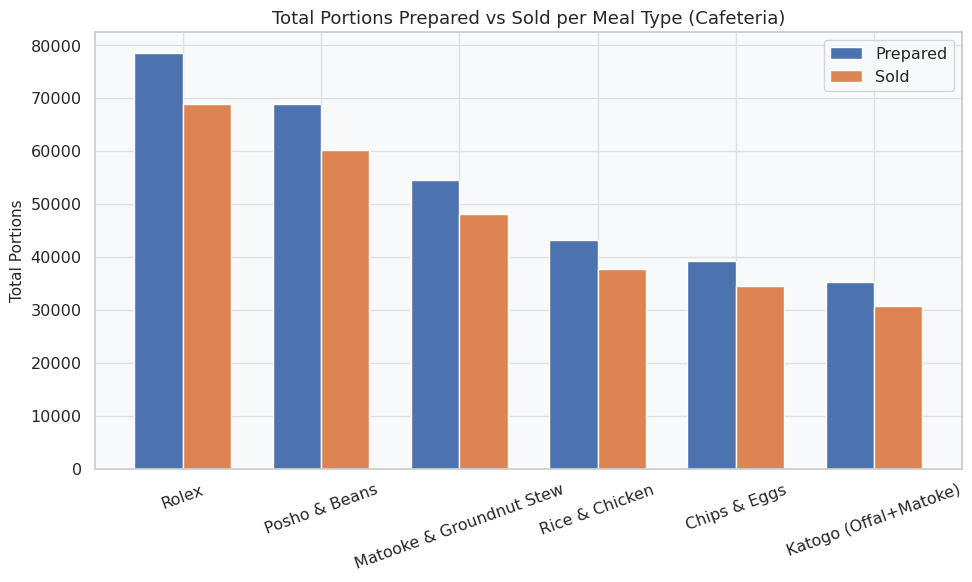

In [ ]:

#1 bar plot comparing total portions prepared vs sold for each meal type in the cafeteria dataset   

# Group and summarize
meal_summary = (
    cafe.groupby('Meal')[['Portions_Prepared', 'Portions_Sold']]
    .sum()
    .sort_values('Portions_Prepared', ascending=False)
)

meals = meal_summary.index
prepared = meal_summary['Portions_Prepared']
sold = meal_summary['Portions_Sold']

x = np.arange(len(meals))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, prepared, width, label='Prepared')
plt.bar(x + width/2, sold, width, label='Sold')

plt.xticks(x, meals, rotation=20)
plt.ylabel('Total Portions')
plt.title('Total Portions Prepared vs Sold per Meal Type (Cafeteria)')
plt.legend()

plt.tight_layout()
plt.show()

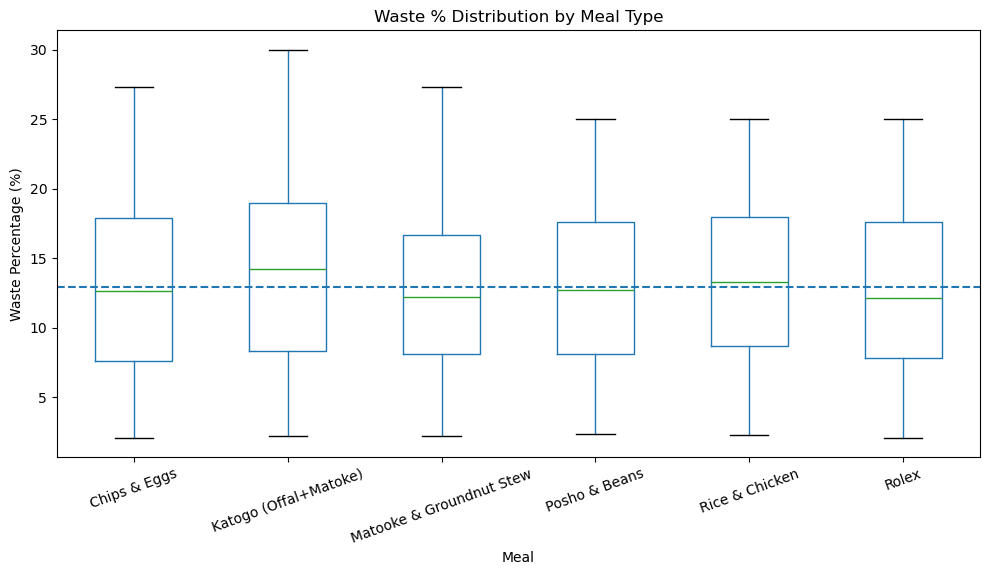

In [ ]:
#2 boxplot showing distribution of waste % by meal type, ordered by median waste %

# Order meals by median waste %
meal_order = (
    cafe.groupby('Meal')['Waste_Pct']
    .median()
    .sort_values(ascending=False)
    .index
)

# Reorder dataframe
ordered_df = cafe.set_index('Meal').loc[meal_order].reset_index()

# Boxplot using pandas
ordered_df.boxplot(
    column='Waste_Pct',
    by='Meal',
    figsize=(10,6),
    grid=False
)

plt.title('Waste % Distribution by Meal Type')
plt.suptitle('')   # Removes automatic pandas subtitle
plt.ylabel('Waste Percentage (%)')
plt.xticks(rotation=20)

# Add overall average line
overall_avg = cafe['Waste_Pct'].mean()
plt.axhline(overall_avg, linestyle='--')

plt.tight_layout()
plt.show()

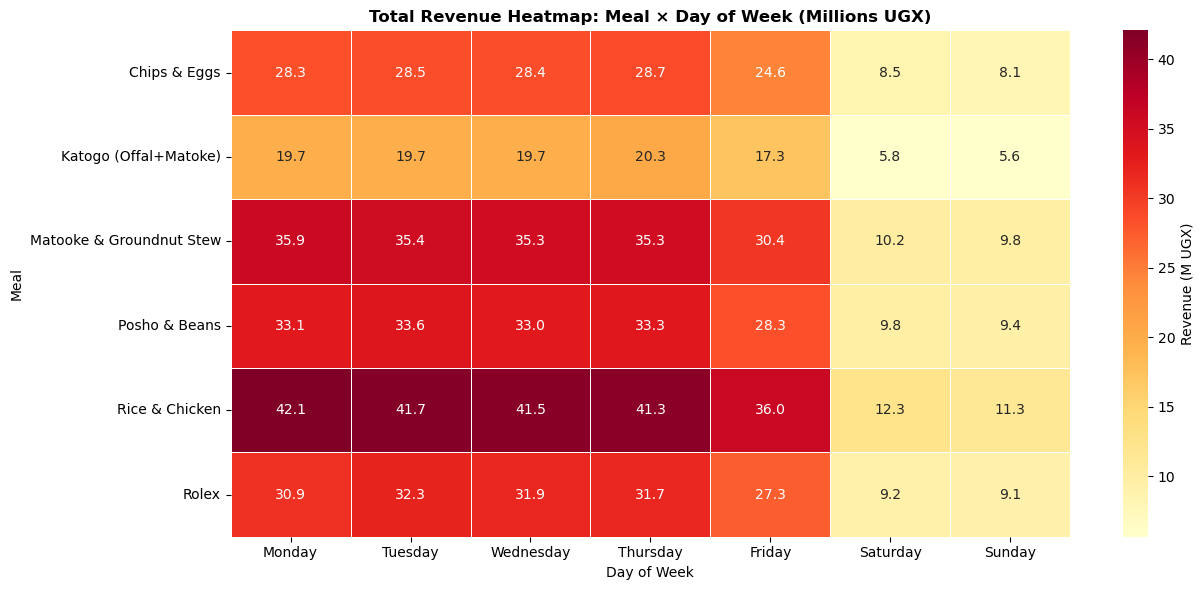

In [ ]:
#3 correlation heatmap of total revenue by meal type and day of week in the cafeteria dataset
pivot_rev = cafe.pivot_table(values='Revenue_UGX', index='Meal',
                              columns='Day_of_Week', aggfunc='sum', observed=True)
pivot_rev = pivot_rev[DOW_ORDER]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot_rev/1e6, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Revenue (M UGX)'})
ax.set_title('Total Revenue Heatmap: Meal × Day of Week (Millions UGX)', fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Meal')
plt.tight_layout()
plt.show()

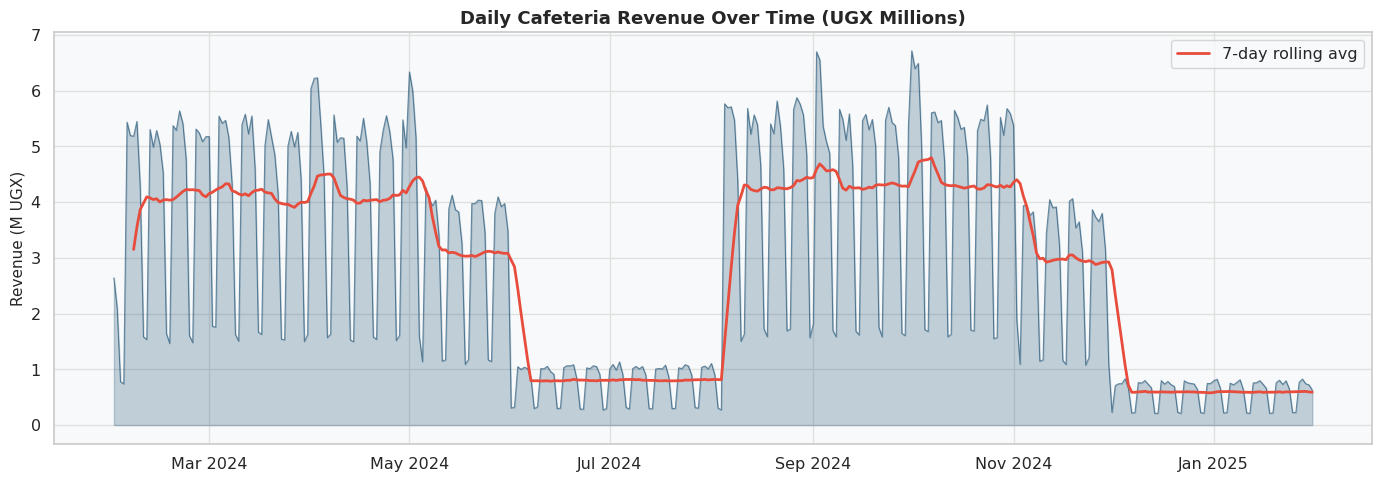

In [ ]:
#4
daily_rev = cafe.groupby('Date')['Revenue_UGX'].sum().reset_index()
daily_rev['Rolling_7'] = daily_rev['Revenue_UGX'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_rev['Date'], daily_rev['Revenue_UGX']/1e6,
                alpha=0.25, color=MAKERERE_COLORS['primary'])
ax.plot(daily_rev['Date'], daily_rev['Revenue_UGX']/1e6,
        color=MAKERERE_COLORS['primary'], linewidth=0.8, alpha=0.6)
ax.plot(daily_rev['Date'], daily_rev['Rolling_7']/1e6,
        color=MAKERERE_COLORS['accent'], linewidth=2, label='7-day rolling avg')
ax.set_title('Daily Cafeteria Revenue Over Time (UGX Millions)', fontweight='bold')
ax.set_ylabel('Revenue (M UGX)')
ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

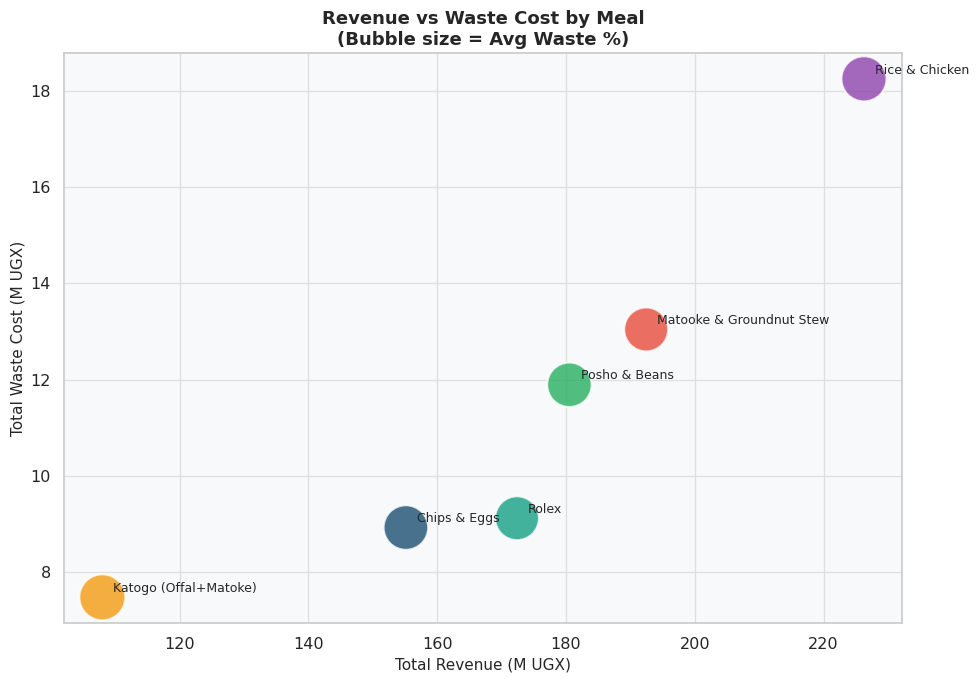

In [43]:
#5 scatter
 
scatter_data = cafe.groupby('Meal').agg(
    Revenue=('Revenue_UGX','sum'),
    Waste=('Waste_Cost_UGX','sum'),
    Avg_Waste_Pct=('Waste_Pct','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(scatter_data['Revenue']/1e6, scatter_data['Waste']/1e6,
                     s=scatter_data['Avg_Waste_Pct']*80,
                     c=MEAL_COLORS[:len(scatter_data)], alpha=0.8, edgecolors='white', linewidth=1.5)
for _, row in scatter_data.iterrows():
    ax.annotate(row['Meal'],
                (row['Revenue']/1e6, row['Waste']/1e6),
                textcoords='offset points', xytext=(8, 4), fontsize=9)
ax.set_title('Revenue vs Waste Cost by Meal\n(Bubble size = Avg Waste %)', fontweight='bold')
ax.set_xlabel('Total Revenue (M UGX)')
ax.set_ylabel('Total Waste Cost (M UGX)')
plt.tight_layout()
plt.show()

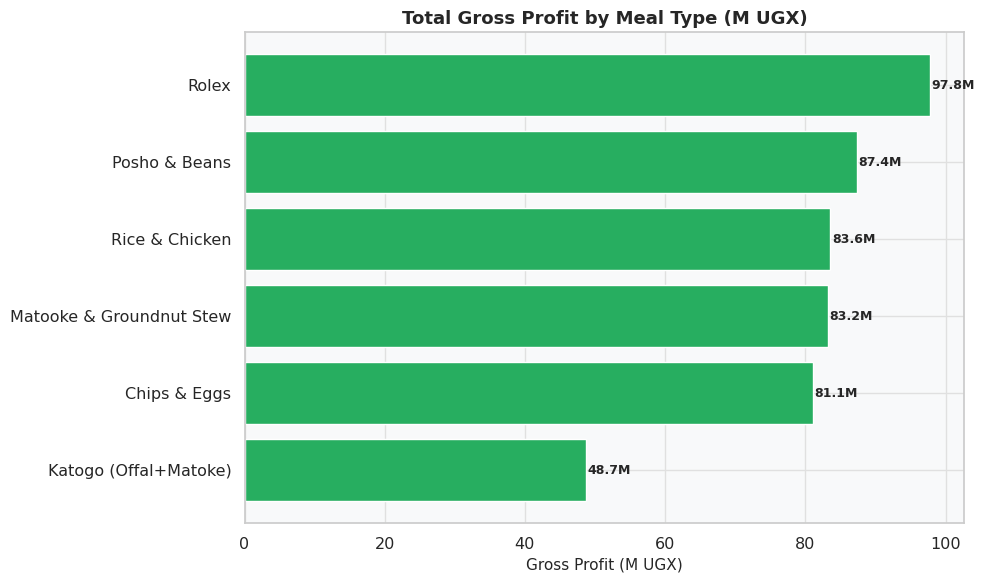

In [ ]:
#6
profit = cafe.groupby('Meal')['Gross_Profit_UGX'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(profit.index, profit.values/1e6,
               color=[MAKERERE_COLORS['green'] if v>0 else MAKERERE_COLORS['accent']
                      for v in profit.values],
               edgecolor='white', linewidth=1)
ax.set_title('Total Gross Profit by Meal Type (M UGX)', fontweight='bold')
ax.set_xlabel('Gross Profit (M UGX)')
for bar in bars:
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.1f}M', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

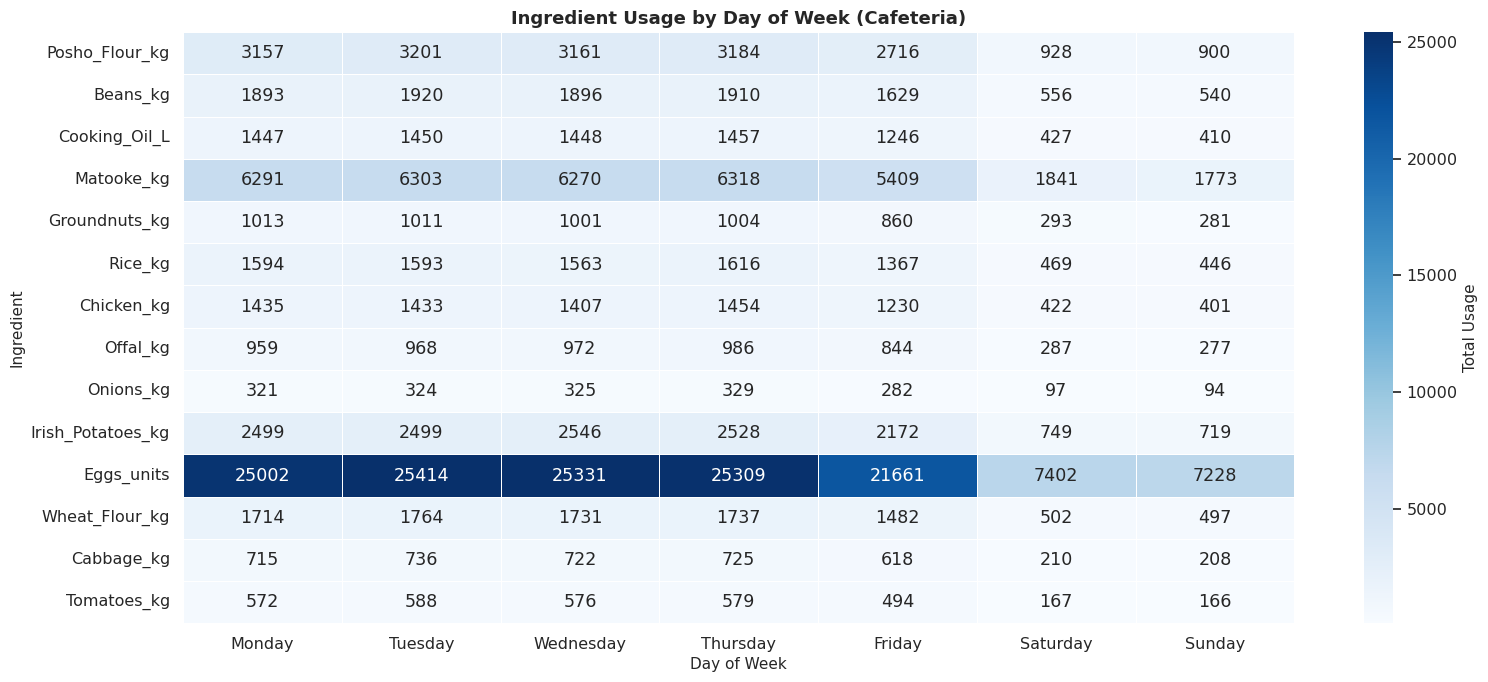

In [44]:
#7
ingredients = ['Posho_Flour_kg','Beans_kg','Cooking_Oil_L','Matooke_kg',
               'Groundnuts_kg','Rice_kg','Chicken_kg','Offal_kg',
               'Onions_kg','Irish_Potatoes_kg','Eggs_units','Wheat_Flour_kg',
               'Cabbage_kg','Tomatoes_kg']
ing_period = cafe.groupby('Day_of_Week', observed=True)[ingredients].sum()
ing_period.index = ing_period.index.astype(str)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(ing_period.T, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Total Usage'})
ax.set_title('Ingredient Usage by Day of Week (Cafeteria)', fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Ingredient')
plt.tight_layout()
plt.show()

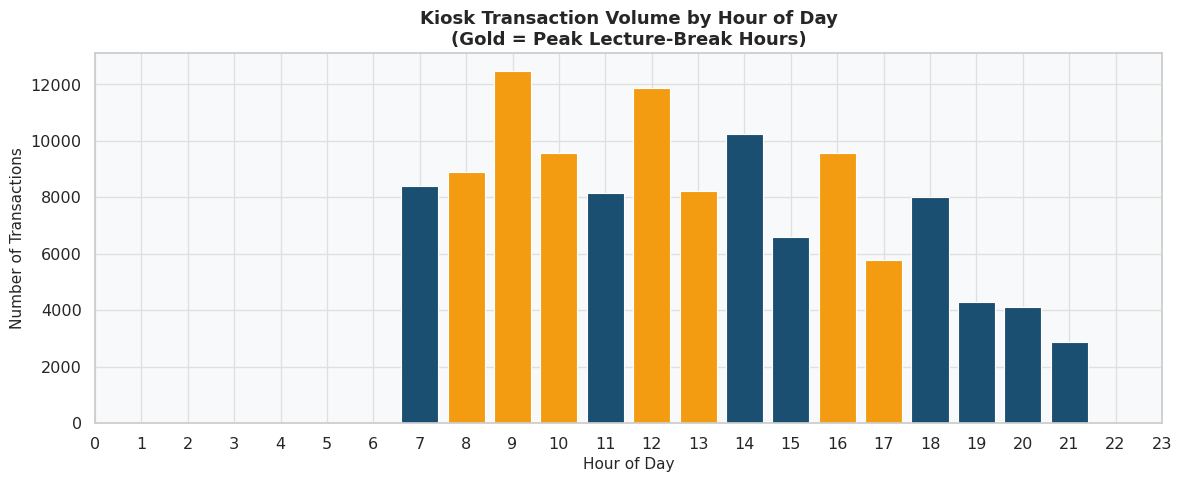

In [45]:
#8
hourly = kiosk.groupby('Hour').size().reset_index(name='Transactions')

fig, ax = plt.subplots(figsize=(12, 5))
colors_h = [MAKERERE_COLORS['secondary'] if h in [8,9,10,12,13,16,17]
            else MAKERERE_COLORS['primary'] for h in hourly['Hour']]
bars = ax.bar(hourly['Hour'], hourly['Transactions'], color=colors_h,
              edgecolor='white', linewidth=0.8)
ax.set_title('Kiosk Transaction Volume by Hour of Day\n(Gold = Peak Lecture-Break Hours)',
             fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Transactions')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

In [22]:
print(kiosk.columns)


Index(['Transaction_ID', 'Date', 'Time', 'Hour', 'Day_of_Week',
       'Academic_Period', 'Is_Weekend', 'Near_Lecture_Start', 'Kiosk_ID',
       'Kiosk_Name', 'Kiosk_Location', 'Item', 'Quantity', 'Unit_Price_UGX',
       'Total_Amount_UGX', 'Payment_Method', 'Price_vs_Base_Pct'],
      dtype='object')


C:\Users\arian\AppData\Local\Temp\ipykernel_35868\3633738922.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(item_rev.index, rotation=20, ha='right')


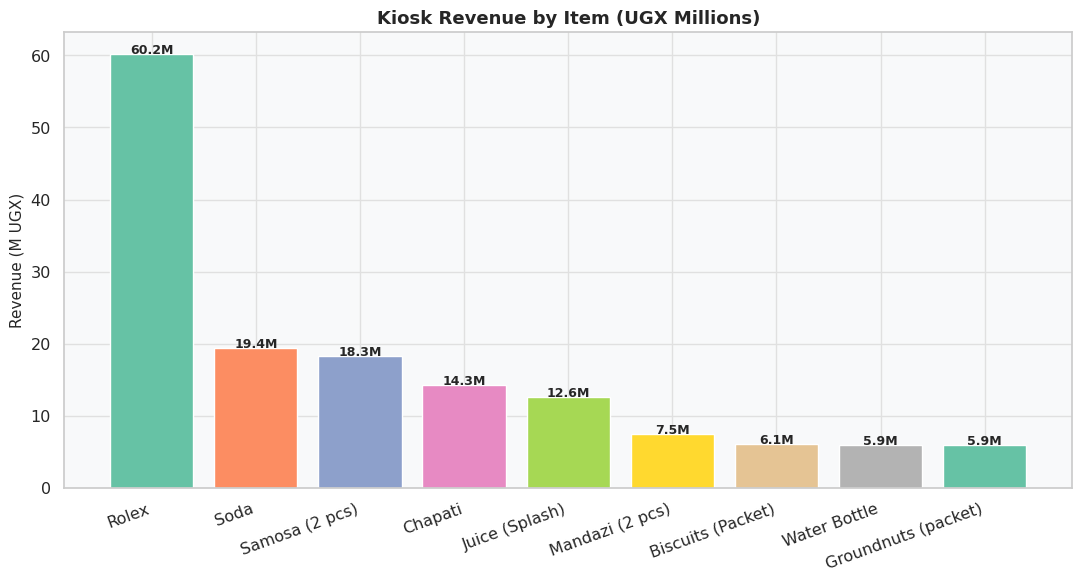

In [46]:
#9
item_rev = kiosk.groupby('Item')['Total_Amount_UGX'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
colors_i = sns.color_palette('Set2', len(item_rev))
bars = ax.bar(item_rev.index, item_rev.values/1e6, color=colors_i,
              edgecolor='white', linewidth=1)
ax.set_title('Kiosk Revenue by Item (UGX Millions)', fontweight='bold')
ax.set_ylabel('Revenue (M UGX)')
ax.set_xticklabels(item_rev.index, rotation=20, ha='right')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.1f}M', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

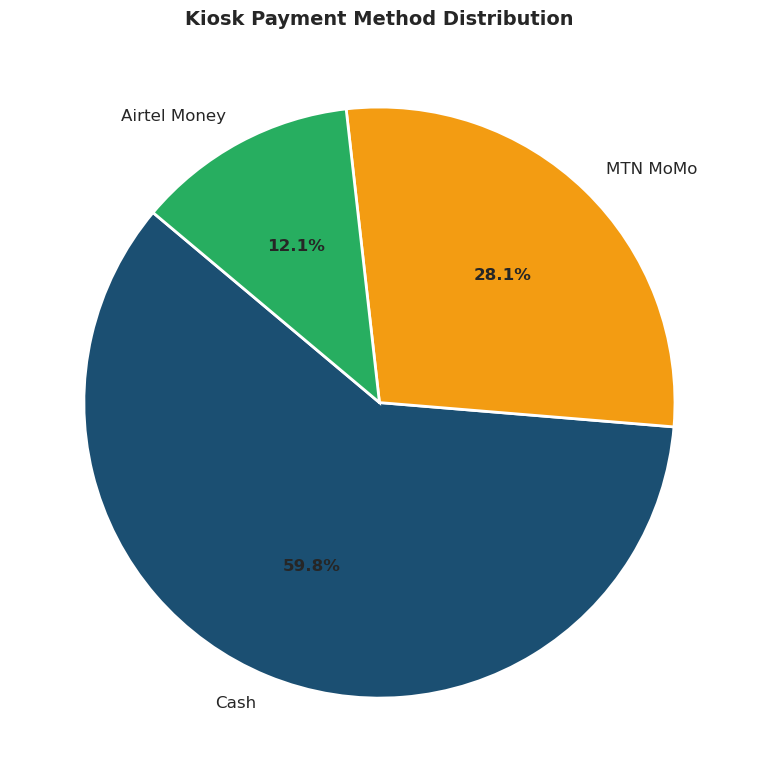

In [47]:
#10
payment = kiosk['Payment_Method'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    payment.values,
    labels=payment.index,
    autopct='%1.1f%%',
    colors=[MAKERERE_COLORS['primary'], MAKERERE_COLORS['secondary'], MAKERERE_COLORS['green']],
    startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':12}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Kiosk Payment Method Distribution', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

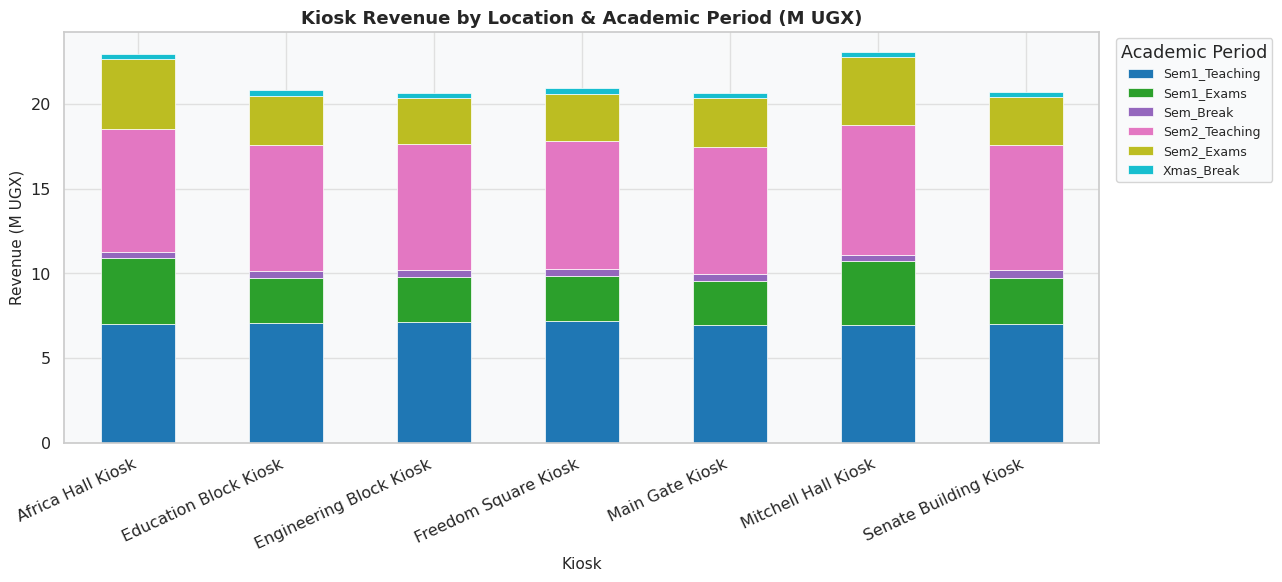

In [48]:
#11
kiosk_loc = kiosk.groupby(['Kiosk_Name','Academic_Period'], observed=True)['Total_Amount_UGX'].sum().unstack(fill_value=0)/1e6

fig, ax = plt.subplots(figsize=(13, 6))
kiosk_loc.plot(kind='bar', stacked=True, ax=ax,
               colormap='tab10', edgecolor='white', linewidth=0.5)
ax.set_title('Kiosk Revenue by Location & Academic Period (M UGX)', fontweight='bold')
ax.set_xlabel('Kiosk')
ax.set_ylabel('Revenue (M UGX)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Academic Period', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

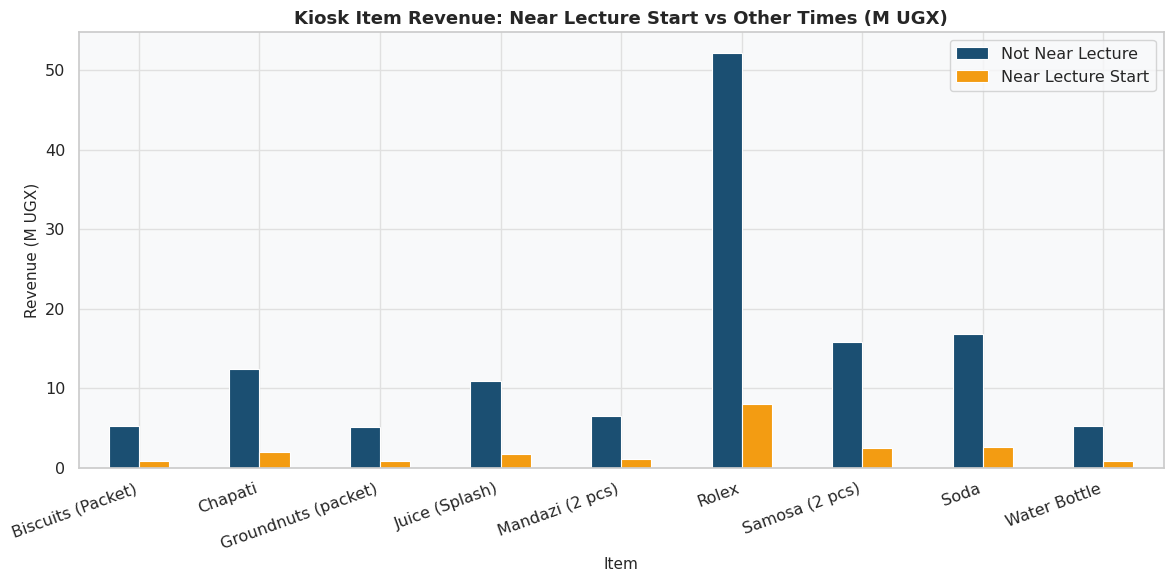

In [49]:
#12
lecture_effect = kiosk.groupby(['Near_Lecture_Start','Item'])['Total_Amount_UGX'].sum().unstack(fill_value=0)/1e6
lecture_effect.index = ['Not Near Lecture','Near Lecture Start']

fig, ax = plt.subplots(figsize=(12, 6))
lecture_effect.T.plot(kind='bar', ax=ax,
                      color=[MAKERERE_COLORS['primary'], MAKERERE_COLORS['secondary']],
                      edgecolor='white', linewidth=0.8)
ax.set_title('Kiosk Item Revenue: Near Lecture Start vs Other Times (M UGX)', fontweight='bold')
ax.set_ylabel('Revenue (M UGX)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

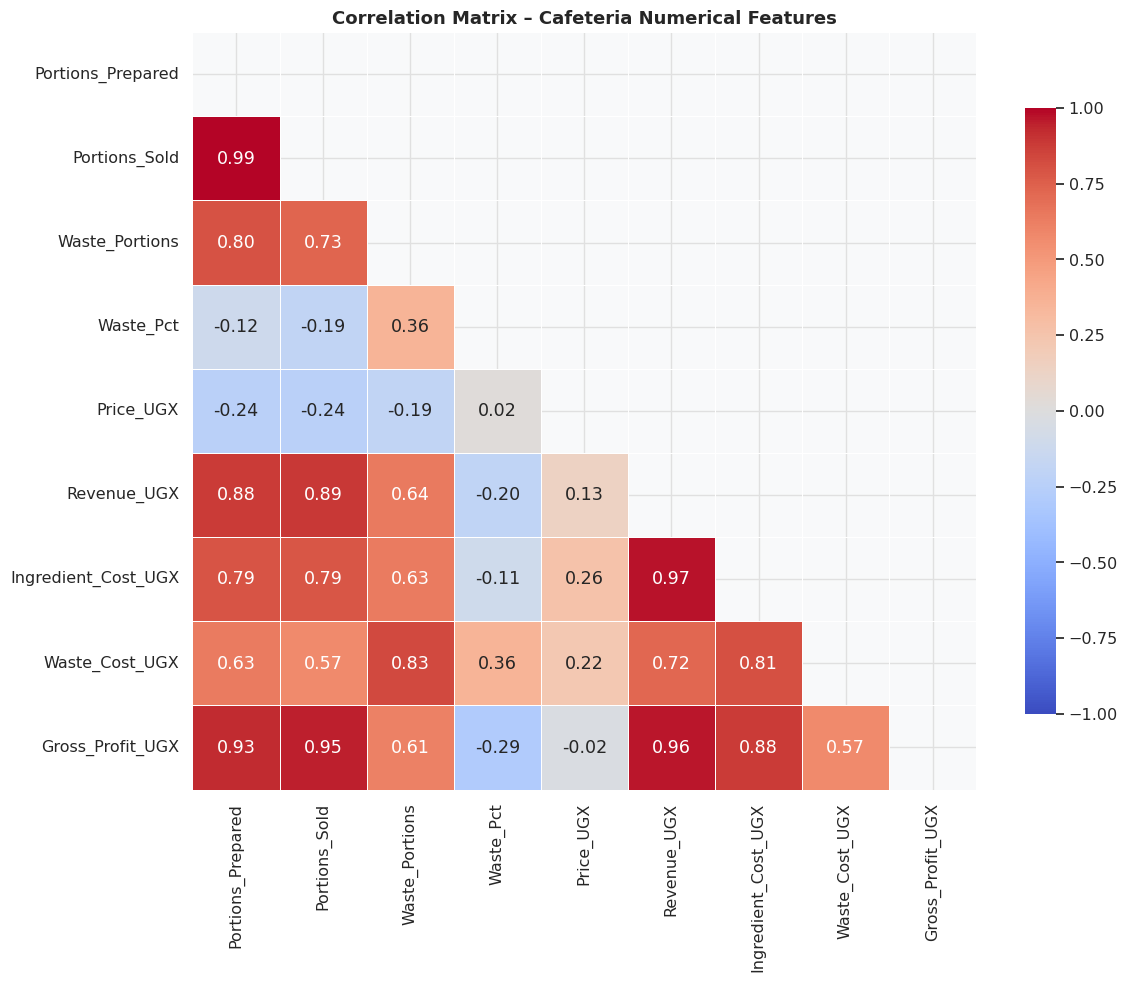

In [50]:



#13
num_cols = ['Portions_Prepared','Portions_Sold','Waste_Portions','Waste_Pct',
            'Price_UGX','Revenue_UGX','Ingredient_Cost_UGX','Waste_Cost_UGX','Gross_Profit_UGX']
corr = cafe[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix – Cafeteria Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

VIZ 16 – Portions Sold Violin by Day


C:\Users\arian\AppData\Local\Temp\ipykernel_35868\1050247671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cafe, x='Day_of_Week', y='Portions_Sold',


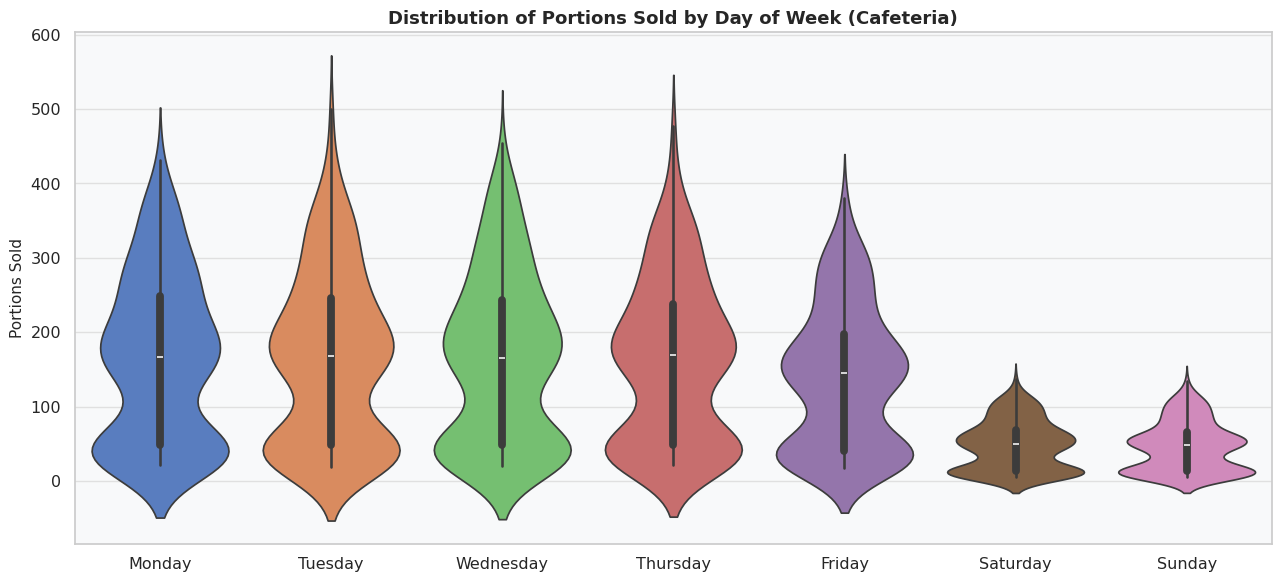

In [ ]:
#14
fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=cafe, x='Day_of_Week', y='Portions_Sold',
               order=DOW_ORDER, palette='muted', ax=ax, inner='box')
ax.set_title('Distribution of Portions Sold by Day of Week (Cafeteria)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Portions Sold')
plt.tight_layout()
plt.show()

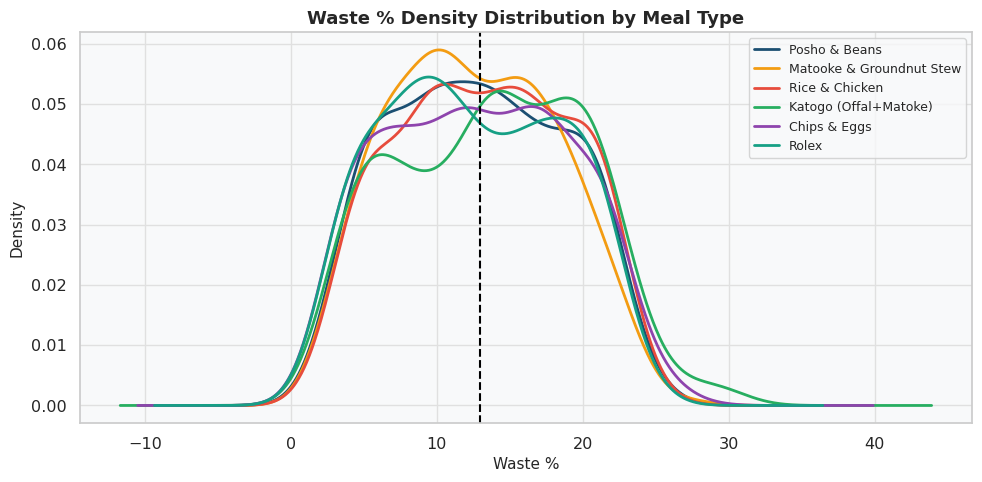

In [51]:
#15
fig, ax = plt.subplots(figsize=(10, 5))
for meal, color in zip(cafe['Meal'].unique(), MEAL_COLORS):
    subset = cafe[cafe['Meal']==meal]['Waste_Pct']
    subset.plot.kde(ax=ax, label=meal, color=color, linewidth=2)
ax.set_title('Waste % Density Distribution by Meal Type', fontweight='bold')
ax.set_xlabel('Waste %')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.axvline(cafe['Waste_Pct'].mean(), color='black', linestyle='--',
           linewidth=1.5, label='Overall Mean')
plt.tight_layout()
plt.show()


C:\Users\arian\AppData\Local\Temp\ipykernel_35868\3417924842.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(cafe_period.index.astype(str), rotation=30, ha='right')
C:\Users\arian\AppData\Local\Temp\ipykernel_35868\3417924842.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(kiosk_period.index.astype(str), rotation=30, ha='right')


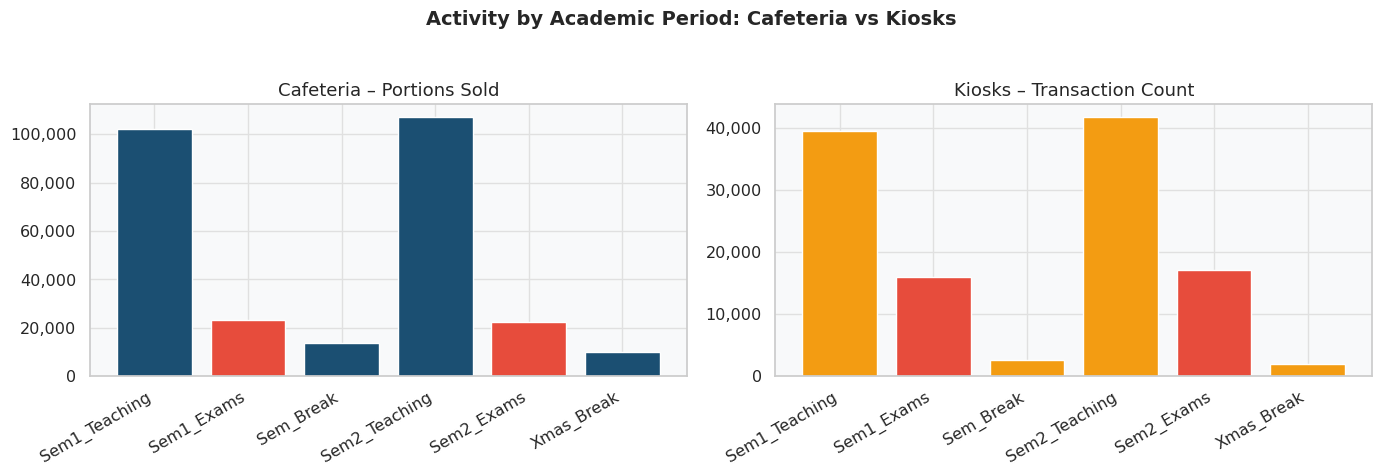

In [52]:
#16
from matplotlib import ticker as mticker


cafe_period  = cafe.groupby('Academic_Period', observed=True)['Portions_Sold'].sum()
kiosk_period = kiosk.groupby('Academic_Period', observed=True).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Activity by Academic Period: Cafeteria vs Kiosks', fontweight='bold', fontsize=14)

colors_p2 = [MAKERERE_COLORS['accent'] if 'Exam' in str(p)
             else MAKERERE_COLORS['primary'] for p in cafe_period.index]
axes[0].bar(cafe_period.index.astype(str), cafe_period.values,
            color=colors_p2, edgecolor='white')
axes[0].set_title('Cafeteria – Portions Sold')
axes[0].set_xticklabels(cafe_period.index.astype(str), rotation=30, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

colors_p3 = [MAKERERE_COLORS['accent'] if 'Exam' in str(p)
             else MAKERERE_COLORS['secondary'] for p in kiosk_period.index]
axes[1].bar(kiosk_period.index.astype(str), kiosk_period.values,
            color=colors_p3, edgecolor='white')
axes[1].set_title('Kiosks – Transaction Count')
axes[1].set_xticklabels(kiosk_period.index.astype(str), rotation=30, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

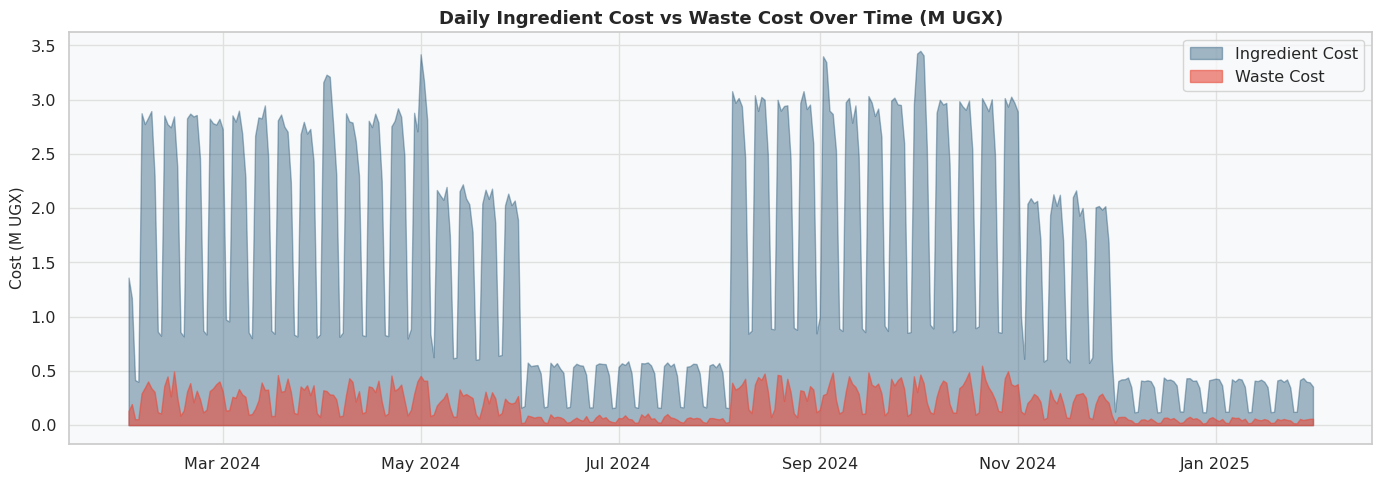

In [53]:
#17
daily_costs = cafe.groupby('Date').agg(
    Ingredient=('Ingredient_Cost_UGX','sum'),
    Waste=('Waste_Cost_UGX','sum')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_costs['Date'], daily_costs['Ingredient']/1e6,
                alpha=0.4, color=MAKERERE_COLORS['primary'], label='Ingredient Cost')
ax.fill_between(daily_costs['Date'], daily_costs['Waste']/1e6,
                alpha=0.6, color=MAKERERE_COLORS['accent'], label='Waste Cost')
ax.set_title('Daily Ingredient Cost vs Waste Cost Over Time (M UGX)', fontweight='bold')
ax.set_ylabel('Cost (M UGX)')
ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

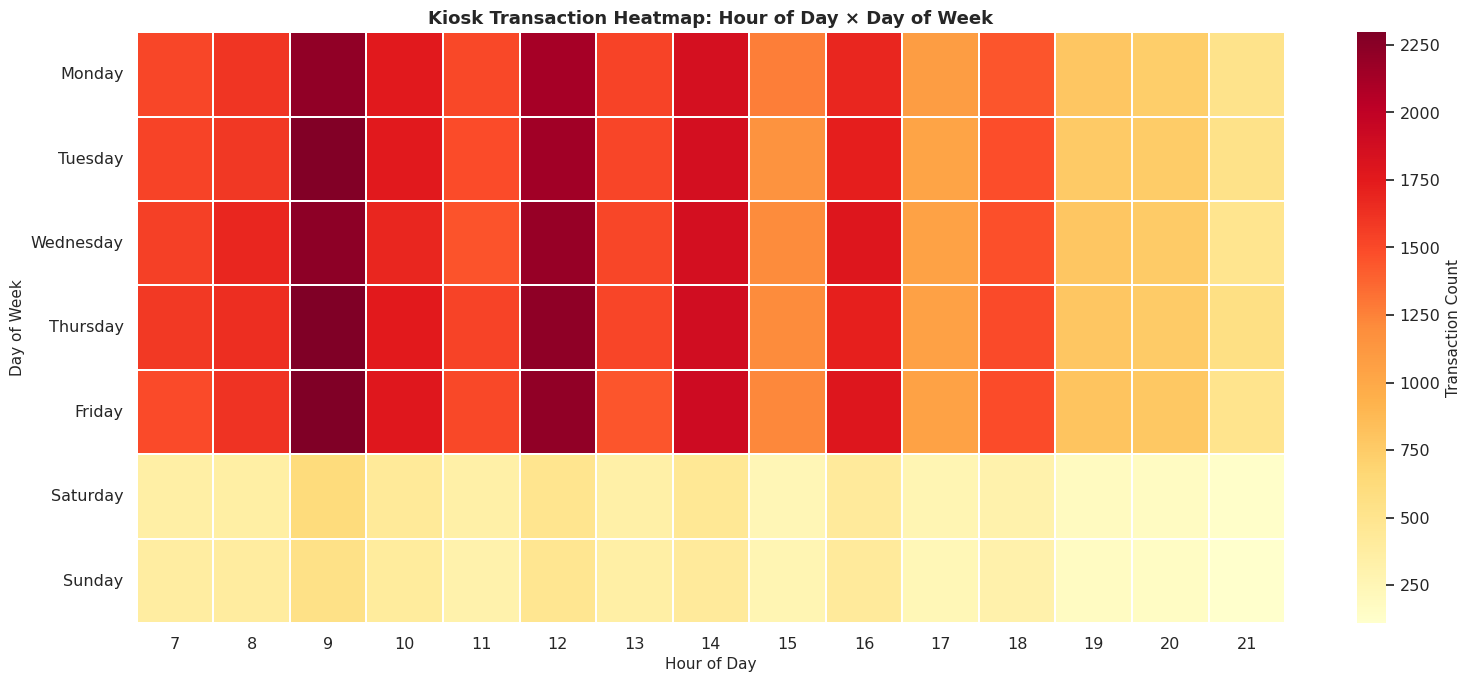

In [54]:
#18
heatmap_data = kiosk.groupby(['Day_of_Week','Hour'], observed=True).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(DOW_ORDER)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Transaction Count'})
ax.set_title('Kiosk Transaction Heatmap: Hour of Day × Day of Week', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()


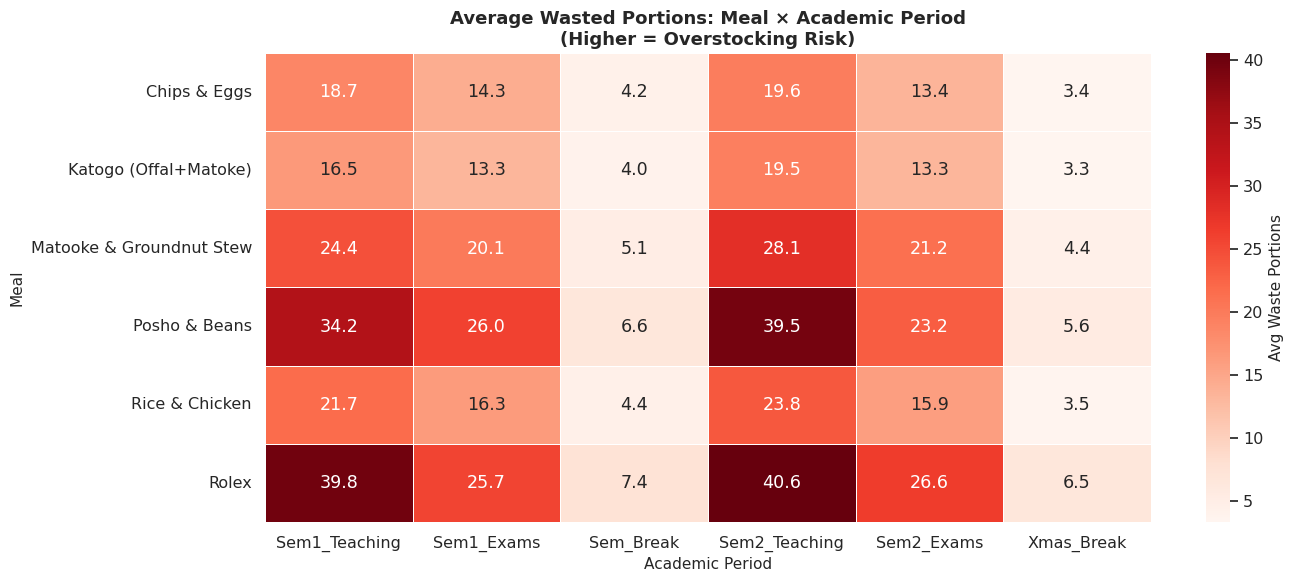

In [55]:
#19
overstock = cafe.groupby(['Meal','Academic_Period'], observed=True)['Waste_Portions'].mean().unstack(fill_value=0)
overstock.columns = overstock.columns.astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(overstock, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Waste Portions'})
ax.set_title('Average Wasted Portions: Meal × Academic Period\n(Higher = Overstocking Risk)',
             fontweight='bold')
ax.set_xlabel('Academic Period')
ax.set_ylabel('Meal')
plt.tight_layout()
plt.show()

C:\Users\arian\AppData\Local\Temp\ipykernel_35868\1404586507.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(eff.index, rotation=20, ha='right')


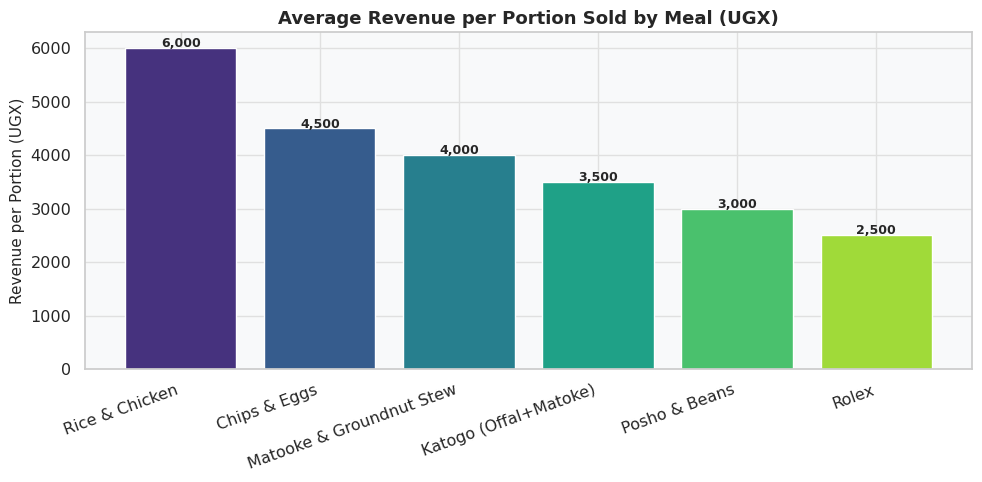

In [56]:
#20
cafe['Revenue_per_Portion'] = cafe['Revenue_UGX'] / cafe['Portions_Sold'].replace(0, np.nan)
eff = cafe.groupby('Meal')['Revenue_per_Portion'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_e = sns.color_palette('viridis', len(eff))
bars = ax.bar(eff.index, eff.values, color=colors_e, edgecolor='white', linewidth=1)
ax.set_title('Average Revenue per Portion Sold by Meal (UGX)', fontweight='bold')
ax.set_ylabel('Revenue per Portion (UGX)')
ax.set_xticklabels(eff.index, rotation=20, ha='right')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

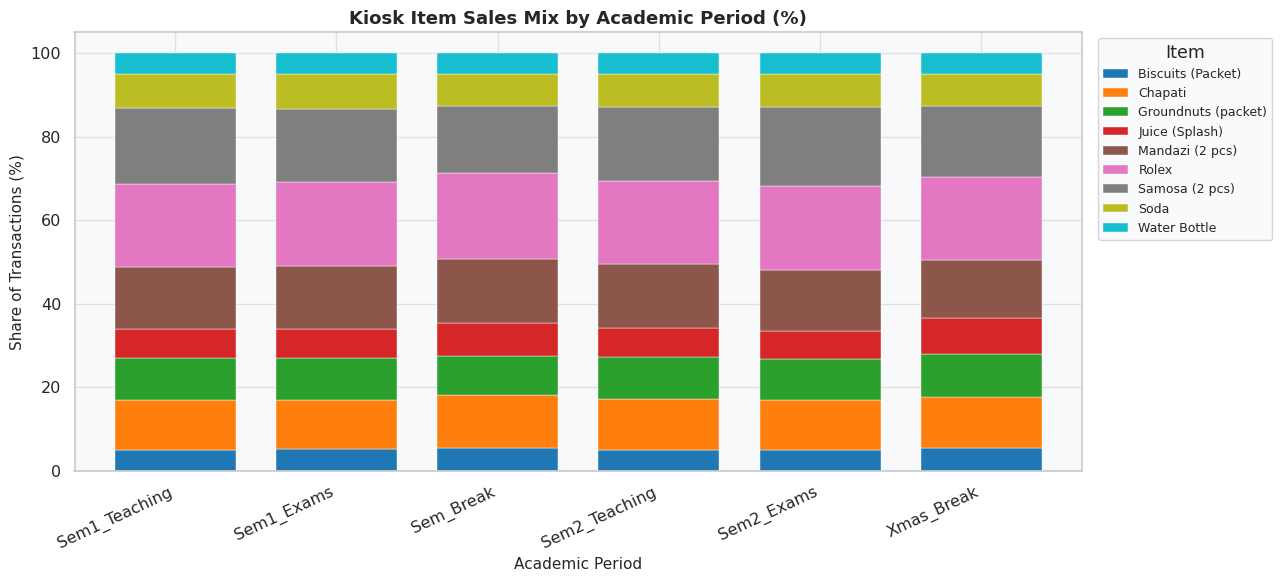

In [57]:
#21
item_period = kiosk.groupby(['Academic_Period','Item'], observed=True).size().unstack(fill_value=0)
item_period_pct = item_period.div(item_period.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
item_period_pct.plot(kind='bar', stacked=True, ax=ax,
                     colormap='tab10', edgecolor='white', linewidth=0.3, width=0.75)
ax.set_title('Kiosk Item Sales Mix by Academic Period (%)', fontweight='bold')
ax.set_ylabel('Share of Transactions (%)')
ax.set_xlabel('Academic Period')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Item', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

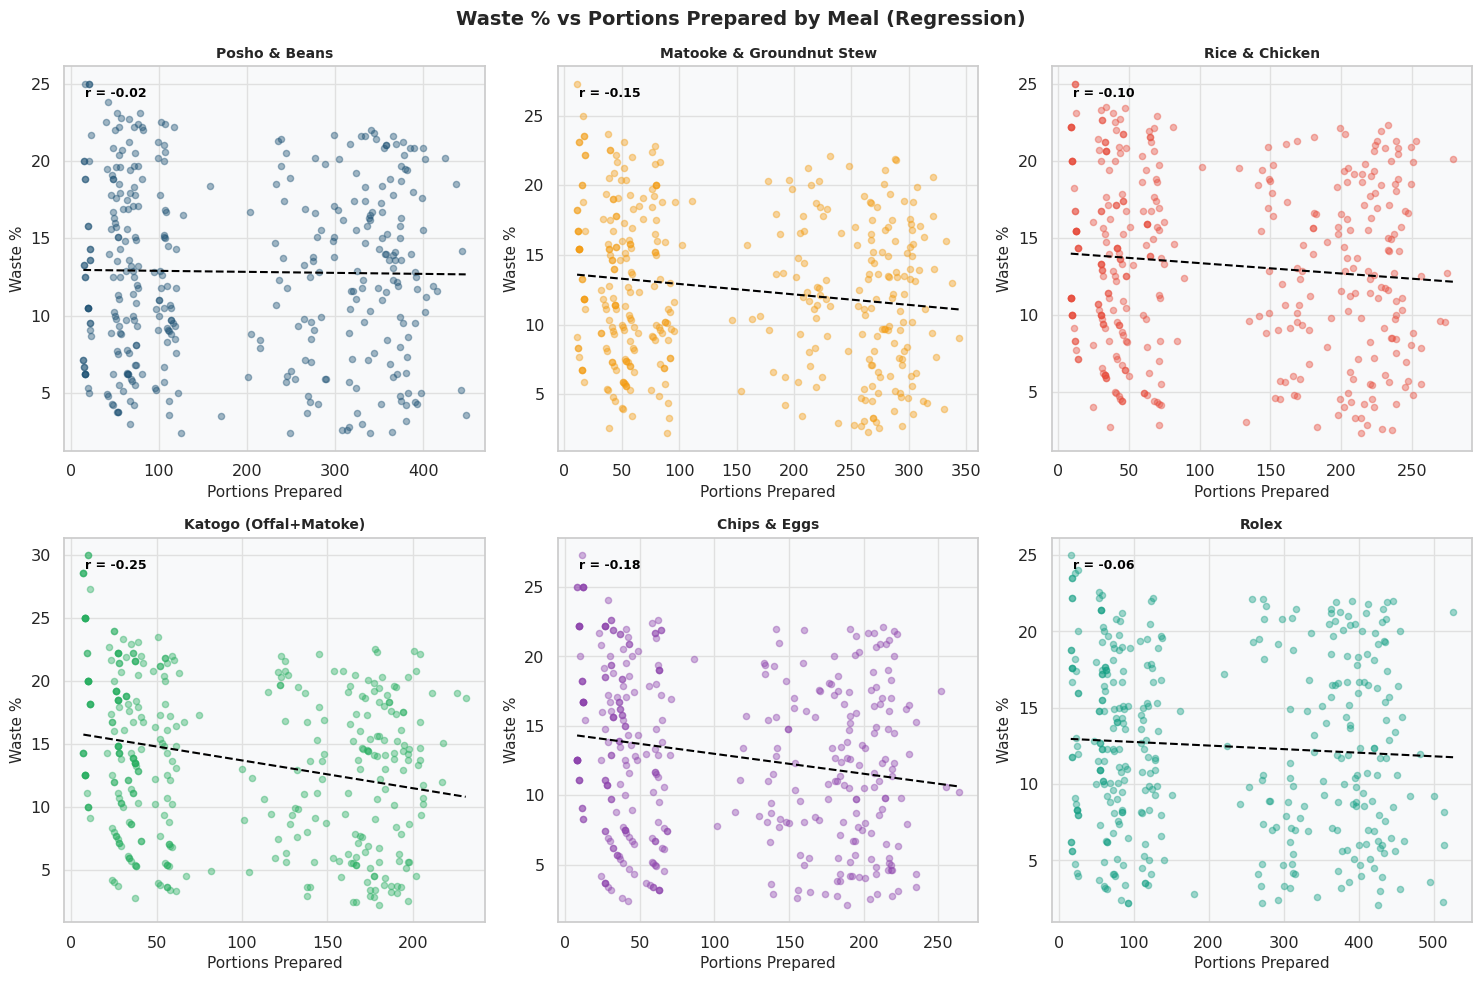

In [ ]:
#22
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Waste % vs Portions Prepared by Meal', fontweight='bold', fontsize=14)
axes = axes.flatten()
for i, (meal, color) in enumerate(zip(cafe['Meal'].unique(), MEAL_COLORS)):
    sub = cafe[cafe['Meal']==meal]
    axes[i].scatter(sub['Portions_Prepared'], sub['Waste_Pct'],
                    alpha=0.4, color=color, s=20)
    m, b = np.polyfit(sub['Portions_Prepared'], sub['Waste_Pct'], 1)
    xline = np.linspace(sub['Portions_Prepared'].min(), sub['Portions_Prepared'].max(), 100)
    axes[i].plot(xline, m*xline+b, color='black', linewidth=1.5, linestyle='--')
    axes[i].set_title(meal, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Portions Prepared')
    axes[i].set_ylabel('Waste %')
    r = np.corrcoef(sub['Portions_Prepared'], sub['Waste_Pct'])[0,1]
    axes[i].text(0.05, 0.92, f'r = {r:.2f}', transform=axes[i].transAxes,
                 fontsize=9, color='black', fontweight='bold')
plt.tight_layout()
plt.show()

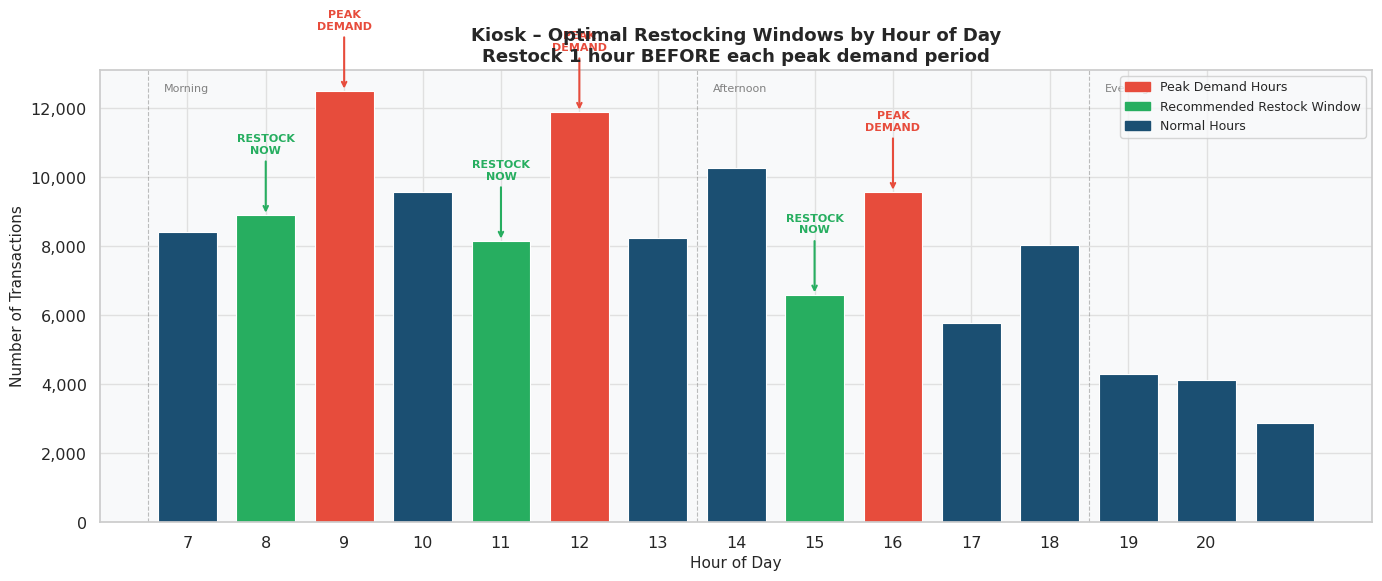


RESTOCK SCHEDULE RECOMMENDATION:
  08:00  → Restock before 09:00 lecture break rush
  11:00  → Restock before 12:00 lunch rush
  15:00  → Restock before 16:00 afternoon break rush


In [ ]:
#23


for col in ['Unit_Price_UGX', 'Total_Amount_UGX']:
    kiosk[col] = kiosk[col].astype(str).str.replace(',', '').astype(float)

# ── Aggregate transactions by hour ──────────────────────────────
hourly = kiosk.groupby('Hour').size().reset_index(name='Transactions')
hourly['Revenue_M'] = kiosk.groupby('Hour')['Total_Amount_UGX'].sum().values / 1e6

# ── Define restocking windows (1 hour BEFORE each peak) ─────────
# Peaks are at 9, 12, 16 (lecture breaks) → restock at 8, 11, 15
PEAK_HOURS    = [9, 12, 16]
RESTOCK_HOURS = [8, 11, 15]

# ── Color code each bar ──────────────────────────────────────────
def bar_color(h):
    if h in PEAK_HOURS:    return '#E74C3C'   # red = peak demand
    if h in RESTOCK_HOURS: return '#27AE60'   # green = restock now
    return '#1B4F72'                           # blue = normal

colors = [bar_color(h) for h in hourly['Hour']]

# ── Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(hourly['Hour'], hourly['Transactions'],
              color=colors, edgecolor='white', linewidth=0.8, width=0.75)

# Annotate restock windows with arrows
for rh in RESTOCK_HOURS:
    row = hourly[hourly['Hour'] == rh]
    if not row.empty:
        y = row['Transactions'].values[0]
        ax.annotate('RESTOCK\nNOW',
                    xy=(rh, y), xytext=(rh, y + 1800),
                    ha='center', fontsize=8, fontweight='bold', color='#27AE60',
                    arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.5))

# Annotate peak hours
for ph in PEAK_HOURS:
    row = hourly[hourly['Hour'] == ph]
    if not row.empty:
        y = row['Transactions'].values[0]
        ax.annotate('PEAK\nDEMAND',
                    xy=(ph, y), xytext=(ph, y + 1800),
                    ha='center', fontsize=8, fontweight='bold', color='#E74C3C',
                    arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5))

# Add vertical dividers for morning / afternoon / evening
for x, label in [(6.5, 'Morning'), (13.5, 'Afternoon'), (18.5, 'Evening')]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(x + 0.2, ax.get_ylim()[1] * 0.97, label,
            fontsize=8, color='grey', va='top')

# Legend
legend_handles = [
    mpatches.Patch(color='#E74C3C', label='Peak Demand Hours'),
    mpatches.Patch(color='#27AE60', label='Recommended Restock Window'),
    mpatches.Patch(color='#1B4F72', label='Normal Hours'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)

ax.set_title('Kiosk – Optimal Restocking Windows by Hour of Day\n'
             'Restock 1 hour BEFORE each peak demand period',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Transactions')
ax.set_xticks(range(7, 21))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.show()

print("\nRESTOCK SCHEDULE RECOMMENDATION:")
print("  08:00  → Restock before 09:00 lecture break rush")
print("  11:00  → Restock before 12:00 lunch rush")
print("  15:00  → Restock before 16:00 afternoon break rush")






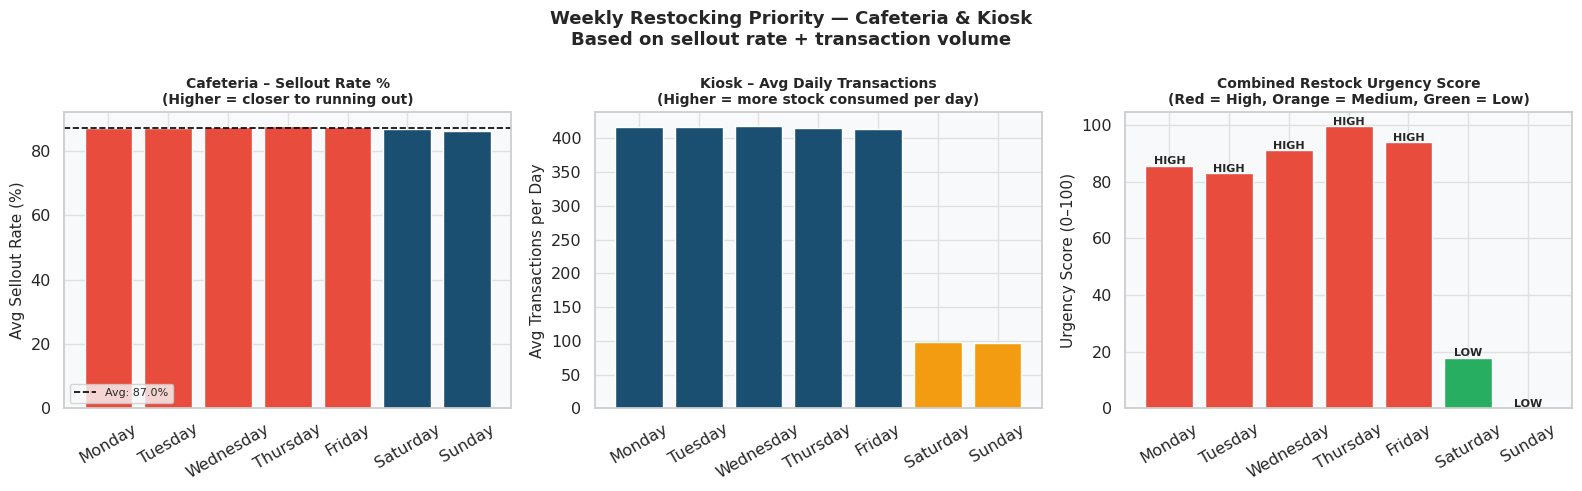


RESTOCK PRIORITY BY DAY:
  Thursday     Score: 99.6  →  HIGH  🔴
  Friday       Score: 93.9  →  HIGH  🔴
  Wednesday    Score: 91.2  →  HIGH  🔴
  Monday       Score: 85.6  →  HIGH  🔴
  Tuesday      Score: 82.9  →  HIGH  🔴
  Saturday     Score: 17.9  →  LOW    🟢
  Sunday       Score: 0.0  →  LOW    🟢


In [ ]:

#24
for col in ['Price_UGX','Revenue_UGX','Ingredient_Cost_UGX','Waste_Cost_UGX','Gross_Profit_UGX']:
    cafe[col] = cafe[col].astype(str).str.replace(',','').astype(float)
for col in ['Unit_Price_UGX','Total_Amount_UGX']:
    kiosk[col] = kiosk[col].astype(str).str.replace(',','').astype(float)

cafe['Day_of_Week']  = pd.Categorical(cafe['Day_of_Week'],  categories=DOW_ORDER, ordered=True)
kiosk['Day_of_Week'] = pd.Categorical(kiosk['Day_of_Week'], categories=DOW_ORDER, ordered=True)

# ── Cafeteria: sellout rate per day (high sellout = near stockout = restock urgently) ──
cafe['Sellout_Rate'] = cafe['Portions_Sold'] / cafe['Portions_Prepared'] * 100
cafe_sellout = (cafe.groupby('Day_of_Week', observed=True)['Sellout_Rate']
                .mean().reindex(DOW_ORDER))

# ── Kiosk: average daily transactions per day ──
kiosk_daily = (kiosk.groupby(['Date','Day_of_Week'], observed=True)
               .size()
               .groupby('Day_of_Week', observed=True)
               .mean()
               .reindex(DOW_ORDER))

# ── Restock urgency score: normalize both 0-100 and average ──
cafe_norm  = (cafe_sellout  - cafe_sellout.min())  / (cafe_sellout.max()  - cafe_sellout.min())  * 100
kiosk_norm = (kiosk_daily   - kiosk_daily.min())   / (kiosk_daily.max()   - kiosk_daily.min())   * 100
urgency    = ((cafe_norm + kiosk_norm) / 2).reindex(DOW_ORDER)

# ── Assign urgency labels ──
def urgency_label(score):
    if score >= 60: return '#E74C3C'    # High
    if score >= 35: return '#F39C12'    # Medium
    return '#27AE60'                    # Low

colors = [urgency_label(s) for s in urgency.values]

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Weekly Restocking Priority — Cafeteria & Kiosk\n'
             'Based on sellout rate + transaction volume',
             fontweight='bold', fontsize=13)

# Panel 1: Cafe sellout rate
axes[0].bar(DOW_ORDER, cafe_sellout.values,
            color=['#E74C3C' if v >= cafe_sellout.mean() else '#1B4F72'
                   for v in cafe_sellout.values],
            edgecolor='white')
axes[0].axhline(cafe_sellout.mean(), color='black', linestyle='--', linewidth=1.2,
                label=f'Avg: {cafe_sellout.mean():.1f}%')
axes[0].set_title('Cafeteria – Sellout Rate %\n(Higher = closer to running out)',
                  fontweight='bold', fontsize=10)
axes[0].set_ylabel('Avg Sellout Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=8)
axes[0].set_facecolor('#F8F9FA')

# Panel 2: Kiosk average daily transactions
axes[1].bar(DOW_ORDER, kiosk_daily.values,
            color=['#F39C12' if d in ['Saturday','Sunday'] else '#1B4F72'
                   for d in DOW_ORDER],
            edgecolor='white')
axes[1].set_title('Kiosk – Avg Daily Transactions\n(Higher = more stock consumed per day)',
                  fontweight='bold', fontsize=10)
axes[1].set_ylabel('Avg Transactions per Day')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[1].set_facecolor('#F8F9FA')

# Panel 3: Combined urgency score
bars = axes[2].bar(DOW_ORDER, urgency.values, color=colors, edgecolor='white')
axes[2].set_title('Combined Restock Urgency Score\n(Red = High, Orange = Medium, Green = Low)',
                  fontweight='bold', fontsize=10)
axes[2].set_ylabel('Urgency Score (0–100)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_facecolor('#F8F9FA')

# Label each bar with urgency level
for bar, score in zip(bars, urgency.values):
    label = 'HIGH' if score >= 60 else ('MED' if score >= 35 else 'LOW')
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 label, ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRESTOCK PRIORITY BY DAY:")
for day, score in urgency.sort_values(ascending=False).items():
    level = 'HIGH  🔴' if score >= 60 else ('MEDIUM 🟡' if score >= 35 else 'LOW    🟢')
    print(f"  {str(day):<12} Score: {score:.1f}  →  {level}")

posx and posy should be finite values
posx and posy should be finite values


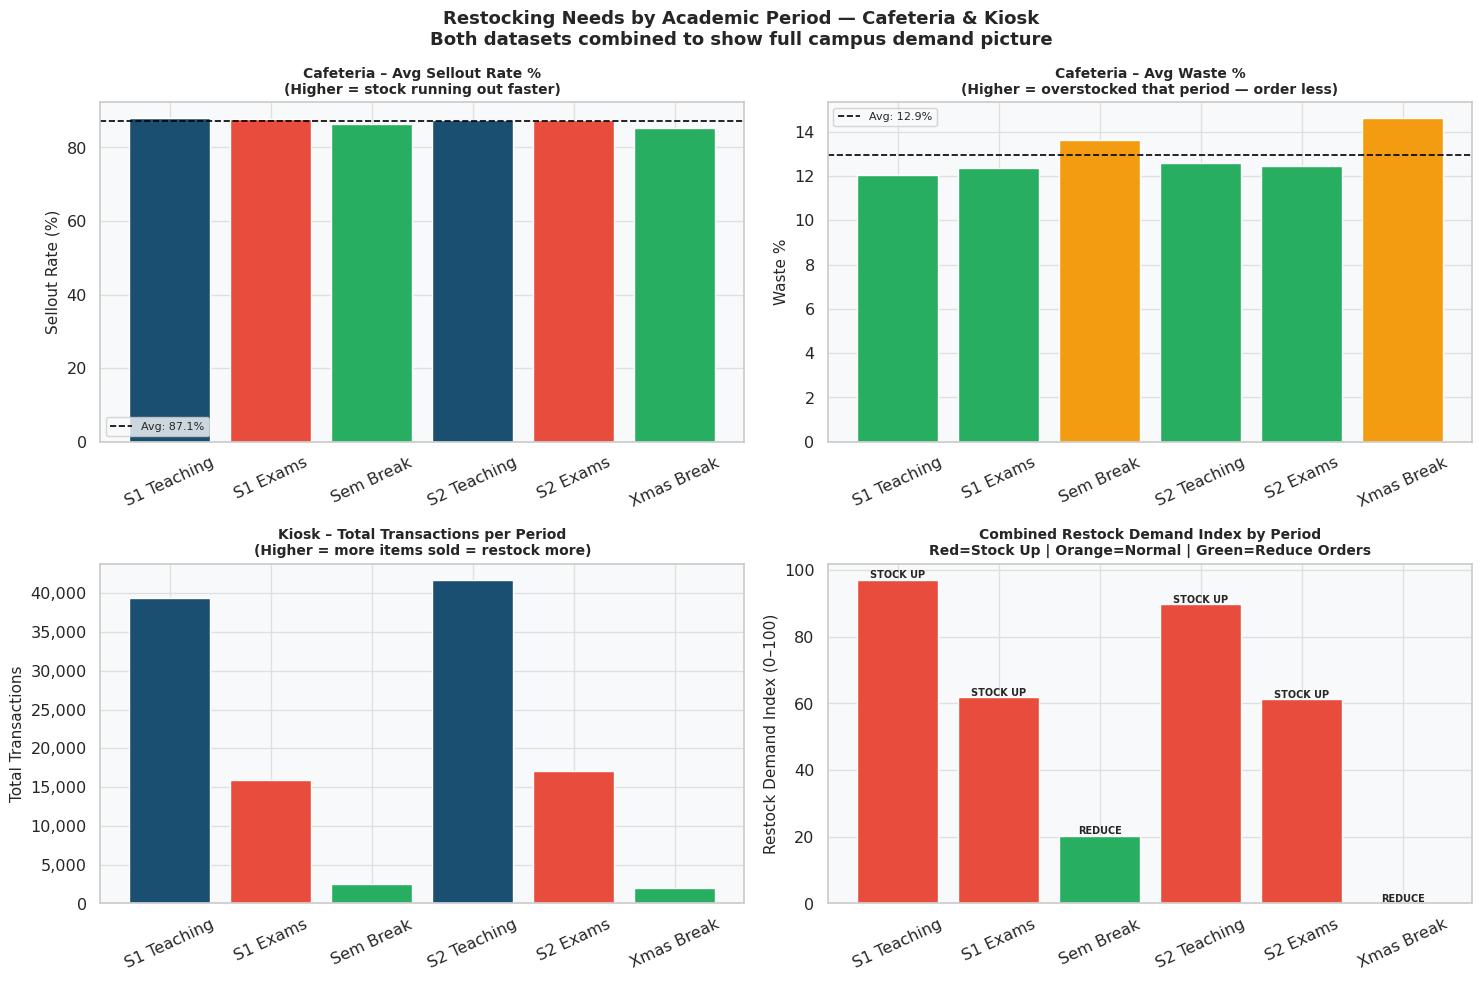


RESTOCK STRATEGY BY ACADEMIC PERIOD:
Period          Cafe Sellout  Waste %   Kiosk Txns          Action
-----------------------------------------------------------------
  Sem1_Teaching        87.9%    12.1%       39,401 STOCK UP
  Sem1_Exams           87.6%    12.4%       15,981 STOCK UP
  Sem_Break            86.4%    13.6%        2,573 REDUCE ORDERS
  Sem2_Teaching        87.4%    12.6%       41,728 STOCK UP
  Sem2_Exams           87.5%    12.4%       17,040 STOCK UP
  Xmas_Break           85.4%    14.6%        1,973 REDUCE ORDERS
  Other                 nan%     nan%          nan REDUCE ORDERS


In [ ]:

#24
for col in ['Price_UGX','Revenue_UGX','Ingredient_Cost_UGX','Waste_Cost_UGX','Gross_Profit_UGX']:
    cafe[col] = cafe[col].astype(str).str.replace(',','').astype(float)
for col in ['Unit_Price_UGX','Total_Amount_UGX']:
    kiosk[col] = kiosk[col].astype(str).str.replace(',','').astype(float)

cafe['Academic_Period']  = pd.Categorical(cafe['Academic_Period'],  categories=PERIOD_ORDER, ordered=True)
kiosk['Academic_Period'] = pd.Categorical(kiosk['Academic_Period'], categories=PERIOD_ORDER, ordered=True)

# ── Cafeteria metrics per period ─────────────────────────────────
cafe['Sellout_Rate'] = cafe['Portions_Sold'] / cafe['Portions_Prepared'] * 100

cafe_period = (cafe.groupby('Academic_Period', observed=True)
               .agg(Avg_Sellout=('Sellout_Rate','mean'),
                    Avg_Waste_Pct=('Waste_Pct','mean'),
                    Total_Portions_Sold=('Portions_Sold','sum'))
               .reindex(PERIOD_ORDER))

# ── Kiosk metrics per period ─────────────────────────────────────
kiosk_period = (kiosk.groupby('Academic_Period', observed=True)
                .agg(Total_Transactions=('Transaction_ID','count'),
                     Total_Revenue=('Total_Amount_UGX','sum'))
                .reindex(PERIOD_ORDER))
kiosk_period['Revenue_M'] = kiosk_period['Total_Revenue'] / 1e6

# ── Restock demand index: high sellout + high transactions = restock more ──
s_norm = (cafe_period['Avg_Sellout']            - cafe_period['Avg_Sellout'].min()) / \
         (cafe_period['Avg_Sellout'].max()       - cafe_period['Avg_Sellout'].min()) * 100
k_norm = (kiosk_period['Total_Transactions']    - kiosk_period['Total_Transactions'].min()) / \
         (kiosk_period['Total_Transactions'].max() - kiosk_period['Total_Transactions'].min()) * 100
restock_index = ((s_norm + k_norm) / 2)

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Restocking Needs by Academic Period — Cafeteria & Kiosk\n'
             'Both datasets combined to show full campus demand picture',
             fontweight='bold', fontsize=13)

period_colors = ['#E74C3C' if 'Exam' in p else
                 '#27AE60' if 'Break' in p else
                 '#1B4F72' for p in PERIOD_ORDER]

# Panel A: Cafeteria sellout rate
axes[0,0].bar(SHORT_LABELS, cafe_period['Avg_Sellout'].values,
              color=period_colors, edgecolor='white')
axes[0,0].axhline(cafe_period['Avg_Sellout'].mean(), color='black',
                  linestyle='--', linewidth=1.2,
                  label=f"Avg: {cafe_period['Avg_Sellout'].mean():.1f}%")
axes[0,0].set_title('Cafeteria – Avg Sellout Rate %\n(Higher = stock running out faster)',
                    fontweight='bold', fontsize=10)
axes[0,0].set_ylabel('Sellout Rate (%)')
axes[0,0].tick_params(axis='x', rotation=25)
axes[0,0].legend(fontsize=8)
axes[0,0].set_facecolor('#F8F9FA')

# Panel B: Cafeteria waste % (inverse — high waste = over-stocked)
axes[0,1].bar(SHORT_LABELS, cafe_period['Avg_Waste_Pct'].values,
              color=['#F39C12' if v > cafe_period['Avg_Waste_Pct'].mean()
                     else '#27AE60' for v in cafe_period['Avg_Waste_Pct'].values],
              edgecolor='white')
axes[0,1].axhline(cafe_period['Avg_Waste_Pct'].mean(), color='black',
                  linestyle='--', linewidth=1.2,
                  label=f"Avg: {cafe_period['Avg_Waste_Pct'].mean():.1f}%")
axes[0,1].set_title('Cafeteria – Avg Waste %\n(Higher = overstocked that period — order less)',
                    fontweight='bold', fontsize=10)
axes[0,1].set_ylabel('Waste %')
axes[0,1].tick_params(axis='x', rotation=25)
axes[0,1].legend(fontsize=8)
axes[0,1].set_facecolor('#F8F9FA')

# Panel C: Kiosk transactions per period
axes[1,0].bar(SHORT_LABELS, kiosk_period['Total_Transactions'].values,
              color=period_colors, edgecolor='white')
axes[1,0].set_title('Kiosk – Total Transactions per Period\n(Higher = more items sold = restock more)',
                    fontweight='bold', fontsize=10)
axes[1,0].set_ylabel('Total Transactions')
axes[1,0].tick_params(axis='x', rotation=25)
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[1,0].set_facecolor('#F8F9FA')

# Panel D: Combined restock demand index
bar_colors_d = ['#E74C3C' if v >= 60 else '#F39C12' if v >= 35 else '#27AE60'
                for v in restock_index.values]
bars = axes[1,1].bar(SHORT_LABELS, restock_index.values,
                     color=bar_colors_d, edgecolor='white')
axes[1,1].set_title('Combined Restock Demand Index by Period\n'
                    'Red=Stock Up | Orange=Normal | Green=Reduce Orders',
                    fontweight='bold', fontsize=10)
axes[1,1].set_ylabel('Restock Demand Index (0–100)')
axes[1,1].tick_params(axis='x', rotation=25)
axes[1,1].set_facecolor('#F8F9FA')

for bar, val in zip(bars, restock_index.values):
    label = 'STOCK UP' if val >= 60 else ('NORMAL' if val >= 35 else 'REDUCE')
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   label, ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRESTOCK STRATEGY BY ACADEMIC PERIOD:")
print(f"{'Period':<15} {'Cafe Sellout':>12} {'Waste %':>8} {'Kiosk Txns':>12} {'Action':>15}")
print("-" * 65)
for i, period in enumerate(PERIOD_ORDER):
    sellout = cafe_period.loc[period,'Avg_Sellout']
    waste   = cafe_period.loc[period,'Avg_Waste_Pct']
    txns    = kiosk_period.loc[period,'Total_Transactions']
    score   = restock_index.loc[period]
    action  = 'STOCK UP' if score >= 60 else ('NORMAL' if score >= 35 else 'REDUCE ORDERS')
    print(f"  {period:<13} {sellout:>11.1f}% {waste:>7.1f}% {txns:>12,.0f} {action}")

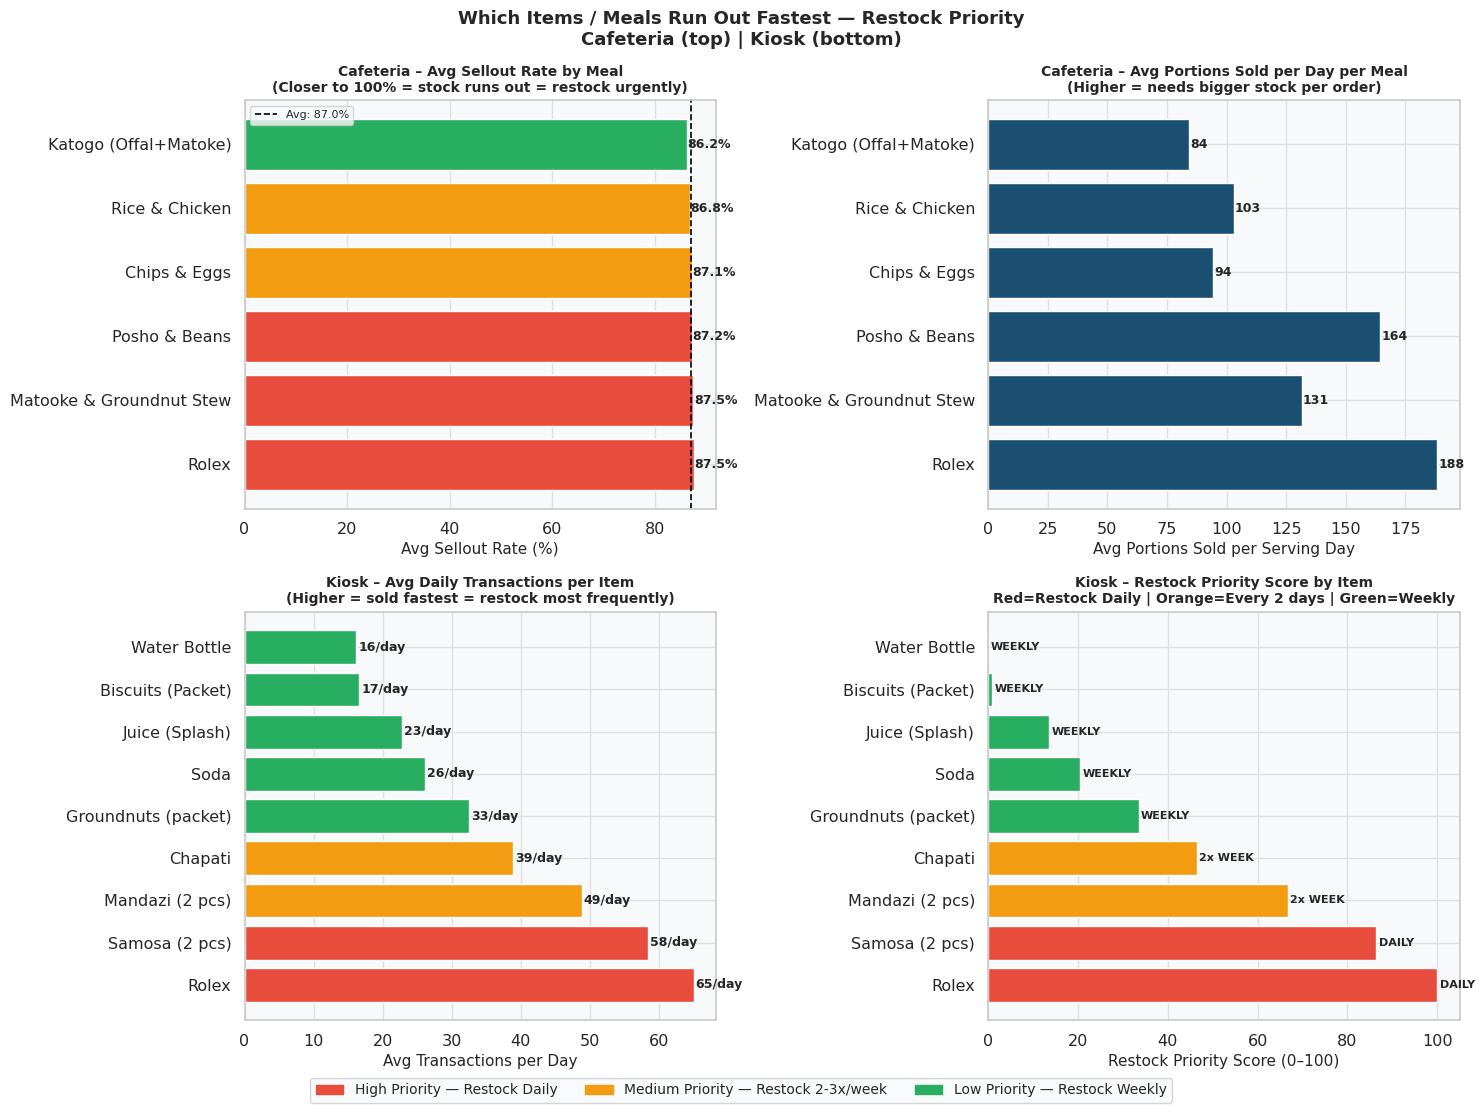


CAFETERIA RESTOCK ORDER (fastest selling first):
  Rolex                        Sellout: 87.5%  →  Daily
  Matooke & Groundnut Stew     Sellout: 87.5%  →  Daily
  Posho & Beans                Sellout: 87.2%  →  Daily
  Chips & Eggs                 Sellout: 87.1%  →  2-3x/week
  Rice & Chicken               Sellout: 86.8%  →  2-3x/week
  Katogo (Offal+Matoke)        Sellout: 86.2%  →  Weekly

KIOSK RESTOCK ORDER (highest demand velocity first):
  Rolex                     Avg 65 txns/day  →  Daily
  Samosa (2 pcs)            Avg 58 txns/day  →  Daily
  Mandazi (2 pcs)           Avg 49 txns/day  →  2-3x/week
  Chapati                   Avg 39 txns/day  →  2-3x/week
  Groundnuts (packet)       Avg 33 txns/day  →  Weekly
  Soda                      Avg 26 txns/day  →  Weekly
  Juice (Splash)            Avg 23 txns/day  →  Weekly
  Biscuits (Packet)         Avg 17 txns/day  →  Weekly
  Water Bottle              Avg 16 txns/day  →  Weekly


In [ ]:


#25
for col in ['Price_UGX','Revenue_UGX','Ingredient_Cost_UGX','Waste_Cost_UGX','Gross_Profit_UGX']:
    cafe[col] = cafe[col].astype(str).str.replace(',','').astype(float)
for col in ['Unit_Price_UGX','Total_Amount_UGX']:
    kiosk[col] = kiosk[col].astype(str).str.replace(',','').astype(float)

# ── CAFETERIA: sellout rate + avg portions sold per day ──────────
cafe['Sellout_Rate'] = cafe['Portions_Sold'] / cafe['Portions_Prepared'] * 100

cafe_meals = (cafe.groupby('Meal')
              .agg(Avg_Sellout_Rate=('Sellout_Rate','mean'),
                   Avg_Portions_Sold=('Portions_Sold','mean'),
                   Avg_Waste_Pct=('Waste_Pct','mean'))
              .sort_values('Avg_Sellout_Rate', ascending=False)
              .reset_index())

# ── KIOSK: avg transactions per day per item (demand velocity) ───
kiosk['Date'] = pd.to_datetime(kiosk['Date'])
n_days = kiosk['Date'].nunique()

kiosk_items = (kiosk.groupby('Item')
               .agg(Total_Transactions=('Transaction_ID','count'),
                    Total_Revenue=('Total_Amount_UGX','sum'))
               .assign(Avg_Daily_Txns=lambda d: d['Total_Transactions'] / n_days)
               .sort_values('Avg_Daily_Txns', ascending=False)
               .reset_index())

# ── Restock urgency: normalize sellout / velocity to 0-100 ───────
def normalize(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

cafe_meals['Urgency']   = normalize(cafe_meals['Avg_Sellout_Rate'])
kiosk_items['Urgency']  = normalize(kiosk_items['Avg_Daily_Txns'])

def urgency_color(score):
    if score >= 70: return '#E74C3C'
    if score >= 40: return '#F39C12'
    return '#27AE60'

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Which Items / Meals Run Out Fastest — Restock Priority\n'
             'Cafeteria (top) | Kiosk (bottom)',
             fontweight='bold', fontsize=13)

# ── Panel A: Cafe sellout rate per meal ──────────────────────────
axes[0,0].barh(cafe_meals['Meal'],
               cafe_meals['Avg_Sellout_Rate'],
               color=[urgency_color(u) for u in cafe_meals['Urgency']],
               edgecolor='white')
axes[0,0].axvline(cafe_meals['Avg_Sellout_Rate'].mean(),
                  color='black', linestyle='--', linewidth=1.2,
                  label=f"Avg: {cafe_meals['Avg_Sellout_Rate'].mean():.1f}%")
axes[0,0].set_title('Cafeteria – Avg Sellout Rate by Meal\n'
                    '(Closer to 100% = stock runs out = restock urgently)',
                    fontweight='bold', fontsize=10)
axes[0,0].set_xlabel('Avg Sellout Rate (%)')
axes[0,0].legend(fontsize=8)
axes[0,0].set_facecolor('#F8F9FA')

for i, (_, row) in enumerate(cafe_meals.iterrows()):
    axes[0,0].text(row['Avg_Sellout_Rate'] + 0.1, i,
                   f"{row['Avg_Sellout_Rate']:.1f}%",
                   va='center', fontsize=9, fontweight='bold')

# ── Panel B: Cafe avg portions sold per serving (demand size) ────
axes[0,1].barh(cafe_meals['Meal'],
               cafe_meals['Avg_Portions_Sold'],
               color='#1B4F72', edgecolor='white')
axes[0,1].set_title('Cafeteria – Avg Portions Sold per Day per Meal\n'
                    '(Higher = needs bigger stock per order)',
                    fontweight='bold', fontsize=10)
axes[0,1].set_xlabel('Avg Portions Sold per Serving Day')
axes[0,1].set_facecolor('#F8F9FA')

for i, (_, row) in enumerate(cafe_meals.iterrows()):
    axes[0,1].text(row['Avg_Portions_Sold'] + 0.5, i,
                   f"{row['Avg_Portions_Sold']:.0f}",
                   va='center', fontsize=9, fontweight='bold')

# ── Panel C: Kiosk avg daily transactions per item ───────────────
axes[1,0].barh(kiosk_items['Item'],
               kiosk_items['Avg_Daily_Txns'],
               color=[urgency_color(u) for u in kiosk_items['Urgency']],
               edgecolor='white')
axes[1,0].set_title('Kiosk – Avg Daily Transactions per Item\n'
                    '(Higher = sold fastest = restock most frequently)',
                    fontweight='bold', fontsize=10)
axes[1,0].set_xlabel('Avg Transactions per Day')
axes[1,0].set_facecolor('#F8F9FA')

for i, (_, row) in enumerate(kiosk_items.iterrows()):
    axes[1,0].text(row['Avg_Daily_Txns'] + 0.3, i,
                   f"{row['Avg_Daily_Txns']:.0f}/day",
                   va='center', fontsize=9, fontweight='bold')

# ── Panel D: Kiosk restock priority ranking ──────────────────────
axes[1,1].barh(kiosk_items['Item'],
               kiosk_items['Urgency'],
               color=[urgency_color(u) for u in kiosk_items['Urgency']],
               edgecolor='white')
axes[1,1].set_title('Kiosk – Restock Priority Score by Item\n'
                    'Red=Restock Daily | Orange=Every 2 days | Green=Weekly',
                    fontweight='bold', fontsize=10)
axes[1,1].set_xlabel('Restock Priority Score (0–100)')
axes[1,1].set_facecolor('#F8F9FA')

for i, (_, row) in enumerate(kiosk_items.iterrows()):
    label = 'DAILY' if row['Urgency'] >= 70 else ('2x WEEK' if row['Urgency'] >= 40 else 'WEEKLY')
    axes[1,1].text(row['Urgency'] + 0.5, i,
                   label, va='center', fontsize=8, fontweight='bold')

# Shared legend
legend_handles = [
    mpatches.Patch(color='#E74C3C', label='High Priority — Restock Daily'),
    mpatches.Patch(color='#F39C12', label='Medium Priority — Restock 2-3x/week'),
    mpatches.Patch(color='#27AE60', label='Low Priority — Restock Weekly'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

print("\nCAFETERIA RESTOCK ORDER (fastest selling first):")
for _, row in cafe_meals.iterrows():
    freq = 'Daily' if row['Urgency'] >= 70 else ('2-3x/week' if row['Urgency'] >= 40 else 'Weekly')
    print(f"  {row['Meal']:<28} Sellout: {row['Avg_Sellout_Rate']:.1f}%  →  {freq}")

print("\nKIOSK RESTOCK ORDER (highest demand velocity first):")
for _, row in kiosk_items.iterrows():
    freq = 'Daily' if row['Urgency'] >= 70 else ('2-3x/week' if row['Urgency'] >= 40 else 'Weekly')
    print(f"  {row['Item']:<25} Avg {row['Avg_Daily_Txns']:.0f} txns/day  →  {freq}")

VIZ 25 – Summary Dashboard


C:\Users\arian\AppData\Local\Temp\ipykernel_35868\4249445307.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


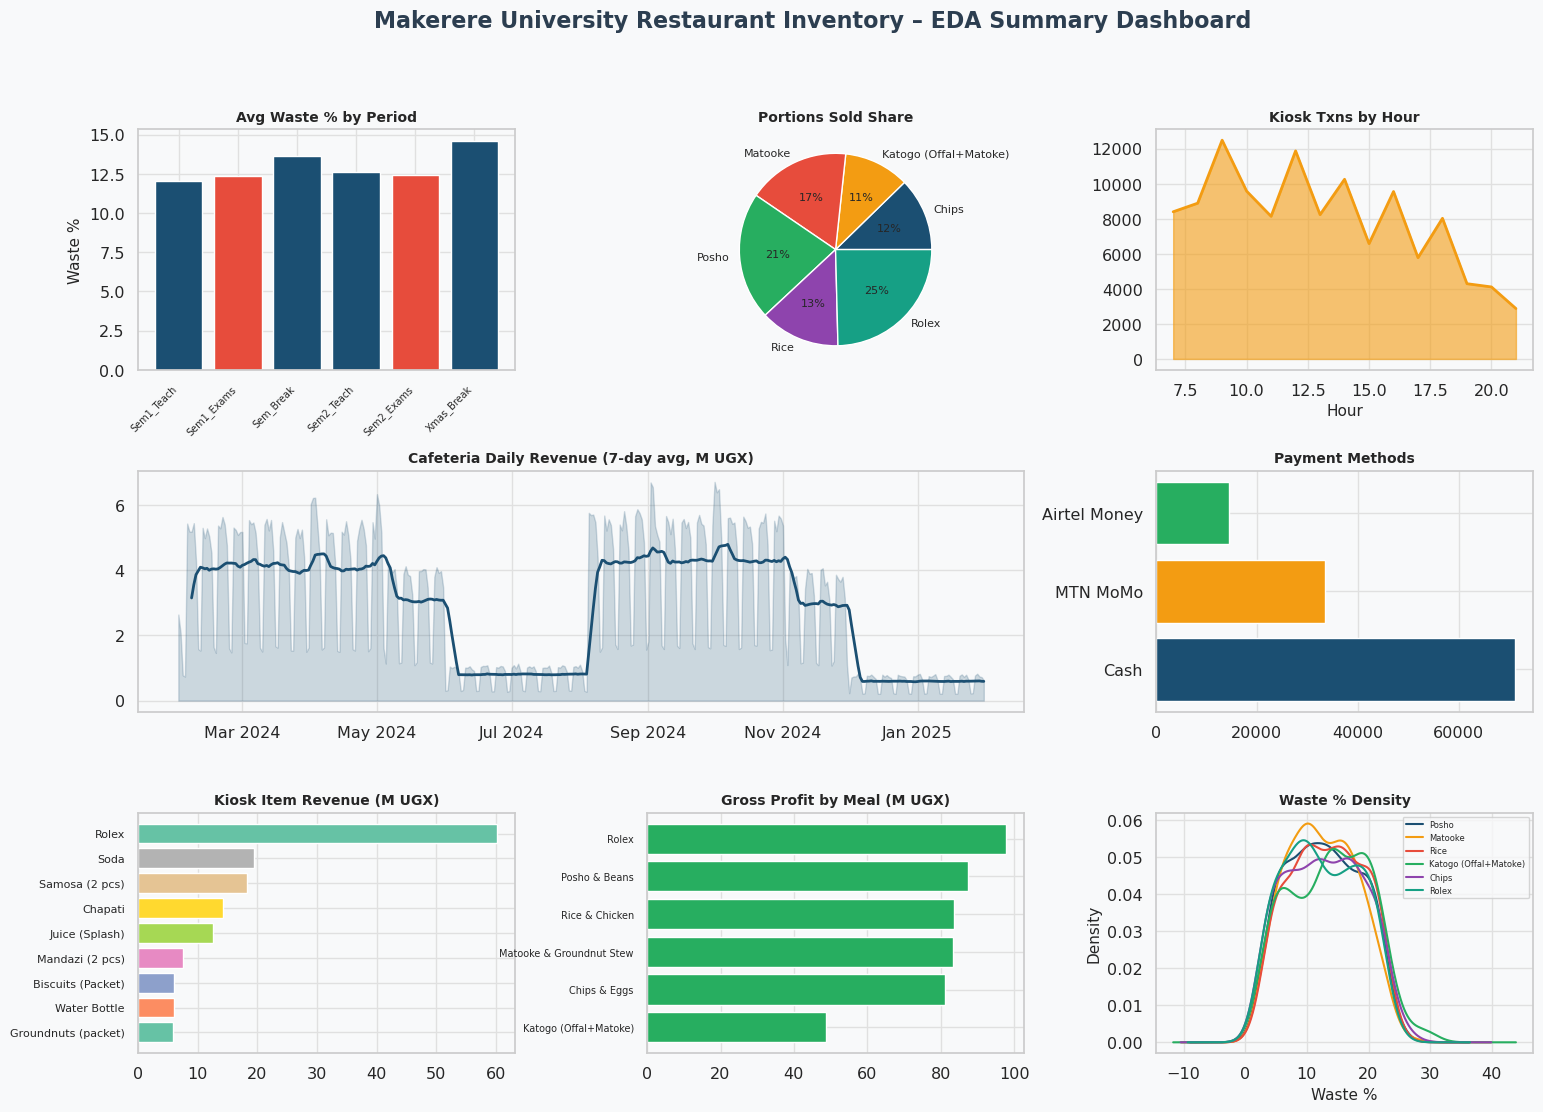

In [ ]:
#26
from matplotlib.gridspec import GridSpec


print("VIZ 25 – Summary Dashboard")
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#F8F9FA')
gs = GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

fig.suptitle('Makerere University Restaurant Inventory – EDA Summary Dashboard',
             fontsize=16, fontweight='bold', color=MAKERERE_COLORS['dark'], y=0.98)

# A: Waste by period
ax1 = fig.add_subplot(gs[0, 0])
pw = cafe.groupby('Academic_Period', observed=True)['Waste_Pct'].mean()
c1 = [MAKERERE_COLORS['accent'] if 'Exam' in str(p) else MAKERERE_COLORS['primary'] for p in pw.index]
ax1.bar(range(len(pw)), pw.values, color=c1)
ax1.set_xticks(range(len(pw)))
ax1.set_xticklabels([str(p)[:10] for p in pw.index], rotation=45, ha='right', fontsize=7)
ax1.set_title('Avg Waste % by Period', fontweight='bold', fontsize=10)
ax1.set_ylabel('Waste %')

# B: Portions sold by meal (pie)
ax2 = fig.add_subplot(gs[0, 1])
ps = cafe.groupby('Meal')['Portions_Sold'].sum()
ax2.pie(ps.values, labels=[m.split('&')[0].strip() for m in ps.index],
        autopct='%1.0f%%', colors=MEAL_COLORS,
        textprops={'fontsize':8}, wedgeprops={'edgecolor':'white'})
ax2.set_title('Portions Sold Share', fontweight='bold', fontsize=10)

# C: Kiosk hourly
ax3 = fig.add_subplot(gs[0, 2])
h = kiosk.groupby('Hour').size()
ax3.fill_between(h.index, h.values, alpha=0.6, color=MAKERERE_COLORS['secondary'])
ax3.plot(h.index, h.values, color=MAKERERE_COLORS['secondary'], linewidth=2)
ax3.set_title('Kiosk Txns by Hour', fontweight='bold', fontsize=10)
ax3.set_xlabel('Hour')

# D: Revenue trend (cafe)
ax4 = fig.add_subplot(gs[1, :2])
dr = cafe.groupby('Date')['Revenue_UGX'].sum()
dr7 = dr.rolling(7).mean()
ax4.fill_between(dr.index, dr.values/1e6, alpha=0.2, color=MAKERERE_COLORS['primary'])
ax4.plot(dr.index, dr7.values/1e6, color=MAKERERE_COLORS['primary'], linewidth=2)
ax4.set_title('Cafeteria Daily Revenue (7-day avg, M UGX)', fontweight='bold', fontsize=10)
ax4.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

# E: Payment split
ax5 = fig.add_subplot(gs[1, 2])
pm = kiosk['Payment_Method'].value_counts()
ax5.barh(pm.index, pm.values,
         color=[MAKERERE_COLORS['primary'], MAKERERE_COLORS['secondary'], MAKERERE_COLORS['green']])
ax5.set_title('Payment Methods', fontweight='bold', fontsize=10)

# F: Top items
ax6 = fig.add_subplot(gs[2, 0])
ti = kiosk.groupby('Item')['Total_Amount_UGX'].sum().sort_values(ascending=True)/1e6
ax6.barh(ti.index, ti.values, color=sns.color_palette('Set2', len(ti)))
ax6.set_title('Kiosk Item Revenue (M UGX)', fontweight='bold', fontsize=10)
ax6.tick_params(axis='y', labelsize=8)

# G: Gross profit by meal
ax7 = fig.add_subplot(gs[2, 1])
gp = cafe.groupby('Meal')['Gross_Profit_UGX'].sum().sort_values()/1e6
ax7.barh(gp.index, gp.values,
         color=[MAKERERE_COLORS['green'] if v>0 else MAKERERE_COLORS['accent'] for v in gp.values])
ax7.set_title('Gross Profit by Meal (M UGX)', fontweight='bold', fontsize=10)
ax7.tick_params(axis='y', labelsize=7)

# H: KDE waste
ax8 = fig.add_subplot(gs[2, 2])
for meal, color in zip(cafe['Meal'].unique(), MEAL_COLORS):
    cafe[cafe['Meal']==meal]['Waste_Pct'].plot.kde(ax=ax8, color=color, linewidth=1.5,
                                                    label=meal.split('&')[0].strip())
ax8.set_title('Waste % Density', fontweight='bold', fontsize=10)
ax8.set_xlabel('Waste %')
ax8.legend(fontsize=6)

plt.tight_layout()
plt.show()



VIZ 01 – Dataset Overview


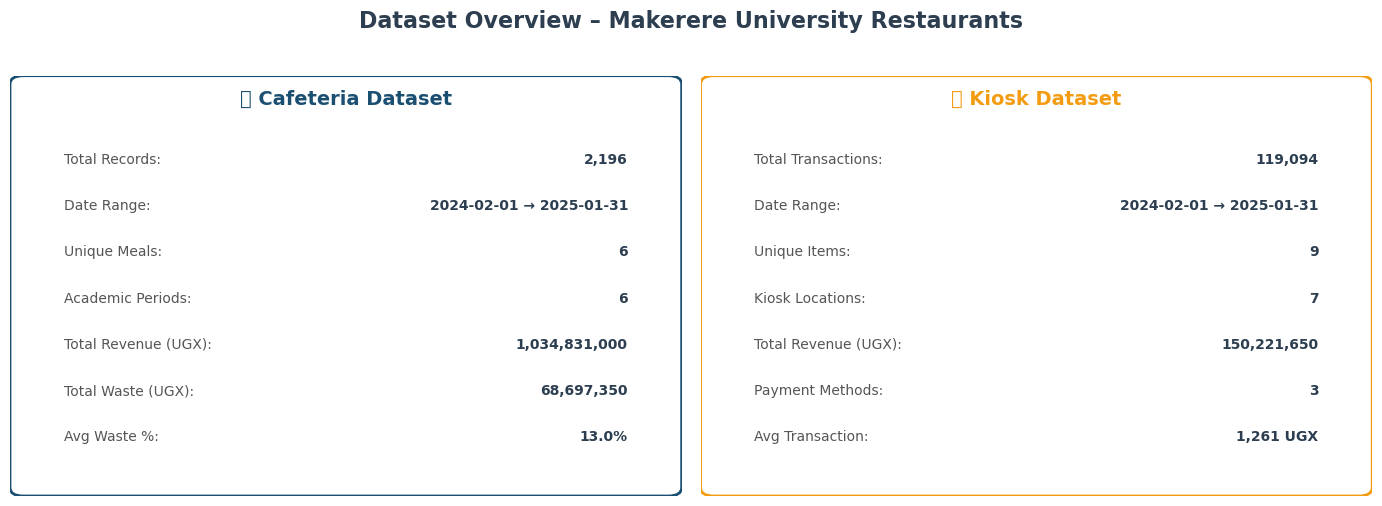

In [ ]:
#27
from matplotlib.patches import FancyBboxPatch

print("VIZ 01 – Dataset Overview")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Overview – Makerere University Restaurants', fontsize=16,
             fontweight='bold', color=MAKERERE_COLORS['dark'], y=1.01)

stats_cafe = {
    'Total Records':       f"{len(cafe):,}",
    'Date Range':          f"{cafe['Date'].min().date()} → {cafe['Date'].max().date()}",
    'Unique Meals':        str(cafe['Meal'].nunique()),
    'Academic Periods':    str(cafe['Academic_Period'].nunique()),
    'Total Revenue (UGX)': f"{cafe['Revenue_UGX'].sum():,.0f}",
    'Total Waste (UGX)':   f"{cafe['Waste_Cost_UGX'].sum():,.0f}",
    'Avg Waste %':         f"{cafe['Waste_Pct'].mean():.1f}%",
}
stats_kiosk = {
    'Total Transactions':  f"{len(kiosk):,}",
    'Date Range':          f"{kiosk['Date'].min().date()} → {kiosk['Date'].max().date()}",
    'Unique Items':        str(kiosk['Item'].nunique()),
    'Kiosk Locations':     str(kiosk['Kiosk_Name'].nunique()),
    'Total Revenue (UGX)': f"{kiosk['Total_Amount_UGX'].sum():,.0f}",
    'Payment Methods':     str(kiosk['Payment_Method'].nunique()),
    'Avg Transaction':     f"{kiosk['Total_Amount_UGX'].mean():,.0f} UGX",
}

for ax, stats, title, color in zip(
        axes,
        [stats_cafe, stats_kiosk],
        ['📋 Cafeteria Dataset', '🏪 Kiosk Dataset'],
        [MAKERERE_COLORS['primary'], MAKERERE_COLORS['secondary']]):
    ax.axis('off')
    ax.set_facecolor('#F0F4F8')
    ax.add_patch(FancyBboxPatch((0.02,0.02), 0.96, 0.96,
                                 boxstyle="round,pad=0.02",
                                 facecolor='white', edgecolor=color, linewidth=2,
                                 transform=ax.transAxes))
    ax.text(0.5, 0.93, title, transform=ax.transAxes,
            fontsize=14, fontweight='bold', ha='center', color=color)
    for i, (k, v) in enumerate(stats.items()):
        y = 0.80 - i * 0.11
        ax.text(0.08, y, f"{k}:", transform=ax.transAxes,
                fontsize=10, color='#555', va='center')
        ax.text(0.92, y, v, transform=ax.transAxes,
                fontsize=10, fontweight='bold', color=MAKERERE_COLORS['dark'],
                ha='right', va='center')

plt.tight_layout()
plt.show()